<h1 style="font-size:25px; font-weight:700; margin-bottom:10px;">
International Roaming Price-Change
</h1>
<div style="font-size:24px; font-family:'Times New Roman', Times, serif; margin-top:0px;">
<i>Estimating the 12-month revenue effect of a proposed international roaming price increase</i>
</div>


<div style="border: 2px solid #9B4A4A; padding: 10px 16px;">
    
## Disclosure

* This notebook reconstructs the methodology used in a client engagement for portfolio purposes. It does not reproduce the engagement or its results.
* The &#36;100 million contribution described in the Introduction provides business context and is not a modeled result.
* All data and modeled results are synthetic. The approximately 50,000-account customer base was designed to support the same type of modeling methodology. All coefficients, distributions, revenue estimates, and segment profiles are derived from synthetic data and do not reflect the engagement’s actual findings.
* The actual findings, production Power BI deliverable, and client-identifying details are proprietary and are not reproduced here.
* What remains faithful to the original work is the methodology, including the model architecture, estimation choices, simulation design, and segmentation logic.
    
</div>

---

## Abstract

- This study evaluates a proposed international roaming price increase using a synthetic book of approximately 50,000 accounts. It estimates the resulting 12-month roaming revenue and identifies the customers most likely to reduce or stop purchasing roaming coverage.
- Two machine-learning models estimate how customers respond to price. The first predicts whether a trip receives no, partial, or full coverage, while the second estimates how much coverage is purchased when a customer reduces usage. A simulation then evaluates revenue across a range of prices and economic conditions.
- The study uses a conservative case to account for evidence that the models may understate both customer response and the size of usage reductions.
- A uniform price increase captures nearly all the projected revenue opportunity. Customer segmentation therefore adds more value by identifying where roaming-pass retention efforts may be needed than by supporting different prices for different customers.
- Revenue remains highest at the upper limit of the tested range. Therefore, the proposed 20% increase is the best option evaluated, not a true revenue-maximizing price beyond that range.
- The results are delivered through an interactive scenario tool that allows users to explore changes in price, customer mix, and economic conditions without requiring a follow-up study.


---

## Introduction

**Business Question:** International roaming was assigned a &#36;100 million contribution toward closing a larger company-wide revenue gap. How much of that target could be delivered through a price change, and how would different customer groups be affected?

**Data and Scope:** The study uses a synthetic customer base of approximately 50,000 accounts, built and validated in a separate data notebook. It estimates the effect on roaming revenue over 12 months. Wireless churn was evaluated separately and excluded because its estimated impact on the study was negligible.

**Study Design:** The study follows four connected stages, with each stage supplying the information required by the next.

| Section                                | Business question answered                                                                                                                                                                            |
| :------------------------------------- | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 01 · Customer Response (State Model)   | How likely is a customer to choose no, partial, or full roaming coverage for a trip at each candidate price?                                                                                          |
| 02 · Purchase Amount (Magnitude Model) | When a customer chooses partial coverage, how much roaming coverage will be purchased?                                                                                                                  |
| 03 · 12-Month Revenue Simulation       | How much 12-month roaming revenue could result at each price under different economic and market conditions, using both fitted and conservative assumptions? |
| 04 · Customer Segments and Delivery    | Which customer groups are most affected, and how can business users explore the results through an interactive scenario tool?                                                                         |

**Model Requirements:**
Because the predicted probabilities enter directly into the revenue calculation, they must be well calibrated, not merely useful for ranking customers. The price-response curves must also be monotonic and smooth, ensuring that simulated customer behavior remains economically coherent across the full range of candidate prices.


---

## Initialize Environment

Initializes the shared imports, plotting style, file paths, constants, and helper functions used throughout the study. Each section then loads only the data and defines only the components it requires.


In [1]:
# Standard library
from pathlib import Path

# Numerical and data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize

# Scikit-Learn: models
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

# Scikit-Learn: preprocessing & calibration
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Scikit-Learn: metrics
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    silhouette_score,
)

# Jupyter
from IPython.display import display


In [2]:
# Plotting Style
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
PALETTE = [ACCENT, '#17369b', '#6f8fe8', RED, MUTED, INK]

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})


In [3]:
# File IO
DATA = Path('data/synthetic')

def load(name):
    '''Load a synthetic table by name, preferring parquet over csv.'''
    
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    
    if csv.exists():
        return pd.read_csv(csv)
    
    raise FileNotFoundError(
        f'{name} not found in {DATA.resolve()}. Run '
        'data/00_generate_and_validate_data.ipynb, then the earlier sections, first.')

def _parquet_available():
    
    for mod in ('pyarrow', 'fastparquet'):
        try:
            __import__(mod)
            return True
        
        except ImportError:
            continue
            
    print('pyarrow/fastparquet not found; writing CSV instead.')
    
    return False

FMT = 'parquet' if _parquet_available() else 'csv'

def save_tables(frames, dest = DATA, with_cols = False):
    '''Write {name: DataFrame} to `dest` as parquet (csv fallback). Returns a row-count summary.'''
    
    dest = Path(dest)
    dest.mkdir(parents = True, exist_ok = True)
    
    names, rows, cols = [], [], []
    for name, df in frames.items():
        path = dest / f'{name}.{FMT}'
        df.to_parquet(path, index = False) if FMT == 'parquet' else df.to_csv(path, index = False)
        names.append(path.name)
        rows.append(len(df))
        cols.append(df.shape[1])
        
    data = {'rows': rows, 'cols': cols} if with_cols else {'rows': rows}
    
    return pd.DataFrame(data, index = names).rename_axis(None)


In [4]:
# Domain Constants & Builders
CLASSES = ['null', 'partial', 'full']
IDX = {c: i for i, c in enumerate(CLASSES)}

DAY_THRESH = 0.70
PRICE_FIRST, PRICE_ADDL = 10.0, 5.0

def reconstruct_label(df, day_thresh = DAY_THRESH):
    '''Reconstruct the three coverage levels from observed quantities alone.'''

    ratio = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower = 1)

    y = pd.Series('full', index = df.index, dtype = object)
    y[(ratio < day_thresh) | (lines < 0.999)] = 'partial'
    y[df['days_bought'] == 0] = 'null'

    return y


def build_features(df):
    '''Non-price feature matrix for the tree stage.'''

    out = pd.DataFrame(index = df.index)
    out['is_business'] = df['is_business'].astype(int)
    out['lines_on_account'] = df['lines_on_account']
    out['tenure_months'] = df['tenure_months']
    out['premium'] = (df['plan_tier'] == 'premium').astype(int)
    out['value_tier'] = (df['plan_tier'] == 'value').astype(int)
    
    for r in ['asia', 'caribbean', 'central_america', 'europe', 'mideast', 'oceania', 'south_america']:  # africa omitted
        out[f'region_{r}'] = (df['region'] == r).astype(int)

    out['month_of_year'] = df['month'] % 12
    out['macro_index'] = df['macro_index']

    return out

def prior_trip_count(df):
    '''Expanding-window count of an account's earlier-month trips (no future leakage).'''

    hist = df[['account_id', 'month']].sort_values(['account_id', 'month'])
    cum = hist.groupby('account_id').cumcount()
    same = hist.groupby(['account_id', 'month']).cumcount()

    return (cum - same).reindex(df.index).fillna(0).astype(int)

def load_trips(with_macro = True):
    '''trips joined to account attributes, optionally with the monthly macro index.'''

    t = load('trips').merge(load('accounts'), on = 'account_id', how = 'left')

    if with_macro:
        t = t.merge(load('macro')[['month', 'macro_index']], on = 'month', how = 'left')

    return t

In [5]:
# Numeric Helpers
_SORTED_CLASSES = sorted(CLASSES)
_PERM = [CLASSES.index(c) for c in _SORTED_CLASSES]

def LL(y_true, P):
    '''log_loss with probability columns given in CLASSES order.

    sklearn's log_loss expects columns in lexicographic label order and does not
    honour `labels=` for column alignment, so the columns are permuted here.
    '''
    
    return log_loss(y_true, P[:, _PERM], labels = _SORTED_CLASSES)


def softmax(eta):
    '''Row-wise softmax, numerically stabilized.'''
    
    e = np.exp(eta - eta.max(axis = 1, keepdims = True))
    
    return e / e.sum(axis=1, keepdims = True)


def logp(p):
    '''Log-probability: the correct scale for a multiclass price shift (see 01 s6).'''
    
    return np.log(np.clip(p, 1e-9, 1.0))


def price_shift_logodds(sweep, mult, ref = 1.0):
    '''Population log-odds shift between price `mult` and `ref`, read from a sweep table
    (index = price multiplier, columns = CLASSES) at the nearest grid point.'''
    
    idx = sweep.index.to_numpy()
    tgt = sweep.iloc[np.argmin(np.abs(idx - mult))][CLASSES].to_numpy()
    base = sweep.iloc[np.argmin(np.abs(idx - ref))][CLASSES].to_numpy()
    
    return logp(tgt) - logp(base)


def apply_price_shift(P0, shift, response_scale = 1.0):
    '''Shift per-trip probabilities `P0` (n x 3, CLASSES order) by `response_scale * shift`
    in log-probability space, renormalized.'''
    
    return softmax(logp(P0) + response_scale * shift)


<hr style="border: none; border-top: 2px solid #4A4A4A;">

# 01 · The State Model

**Purpose:** Predicts, for each customer trip and candidate price, the probability distribution across three coverage levels: null, partial, and full. Because these probabilities enter directly into the revenue calculation, they must be well calibrated. A predicted 15% probability of partial coverage should correspond to approximately 15% of comparable trips receiving partial coverage.

**Architecture:** The model has two stages. Stage 1 estimates baseline state probabilities at the standard price using customer and trip characteristics other than price, including travel behavior, number of lines, plan tier, tenure, region, and time of year. Stage 2 adds a constrained price component that estimates how those probabilities change as price rises or falls. This produces smooth, monotonic price-response curves across the candidate range, including intermediate prices not previously charged.

| Stage | Method                                           | Why this model                                                                                                                                                                                          |
| :---- | :----------------------------------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| 1     | Gradient-Boosted Trees on Non-Price Features     | Customer behavior is nonlinear and includes many interactions, making a flexible tree model appropriate. At this stage, predictive flexibility is more important than coefficient-level interpretation. |
| 2     | Multinomial Logit with Stage 1 as a Fixed Offset | The price response must remain smooth and monotonic across the candidate range. A sign-constrained parametric price component provides that structure, while a tree alone does not.                     |

**Design Requirements:** Because the model feeds a forward-looking revenue simulation, its outputs must be statistically reliable and economically coherent. The following requirements govern how labels are constructed, data is split, probabilities are calibrated, the price effect is estimated, and the response is tested beyond the original market-test regions.

| Requirement                               | Where                              | Reasoning                                                                                                                                                                                                        |
| :---------------------------------------- | :--------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Labels Reconstructed from Observed Data   | Label Construction                 | The behavioral state is not recorded and must be derived from observed trip quantities, including days and lines purchased relative to days and lines traveled.                                                  |
| Time-Based Split                          | Train, Calibration, and Test Split | The model is used to forecast future behavior, so training, calibration, and testing are separated in time. A random split could allow future patterns to influence model development and overstate performance. |
| Calibrated Probabilities                  | Final Probability Model            | The revenue calculation multiplies each probability by a dollar value, so probabilities must be accurate in level, not merely useful for ranking customers.                                                      |
| Price Effect Separated from Other Factors | Price Identification and Stage 2   | Historical price changes were not assigned randomly. The price relationship must therefore be estimated after accounting for factors such as customer characteristics, region, and season.                       |
| Monotonic and Smooth Price Response       | Stage 2                            | The modeled response must move consistently in the expected direction as price changes, without implausible reversals or discontinuities.                                                                        |
| Price-Response Transferability Tested     | Regional Holdout                   | The price response is estimated using market-test data but applied to the full customer base, so its performance must be tested outside the original market-test regions.                                        |


In [6]:
# Load data
trips = load_trips()
print(f'{len(trips):,} trips \u00b7 {trips.account_id.nunique():,} accounts \u00b7 {trips.month.nunique()} months')

94,579 trips · 29,406 accounts · 24 months


<hr style="border: none; border-top: 2px solid #4A4A4A;">

## 1 · Label Reconstruction

**Purpose:** Reconstructs three coverage levels from observed trip data because the underlying behavioral state is not recorded in production.

**Design Notes:** Coverage level is the outcome predicted by the state model and an input to the revenue calculation. For each customer trip and candidate price, the model estimates the probability of no, partial, or full coverage. Expected revenue is then calculated by multiplying each probability by the revenue associated with that coverage level.

Coverage level is determined by the share of travel days covered by a pass and whether every traveling line is covered:

* `day coverage = days_bought / days_traveled`
* `line coverage = lines_active / lines_traveling`

| Level     | Meaning                                                      | Rule per trip                                                            | Notes                                                                                               |
| :-------- | :----------------------------------------------------------- | :----------------------------------------------------------------------- | :-------------------------------------------------------------------------------------------------- |
| `null`    | No roaming pass purchased                                    | `days_bought == 0`                                                       | The customer traveled but used an alternative such as a local SIM, eSIM, Wi-Fi, or no connectivity. |
| `partial` | Some coverage purchased, but below the full-coverage rule    | Day coverage is below 70%, or at least one traveling line is not covered | May result from fewer covered days, fewer covered lines, or both.                                   |
| `full`    | Broad trip coverage under the study’s operational definition | Day coverage is at least 70%, and every traveling line is covered        | The 70% threshold defines broad trip coverage without requiring a pass for every travel day.        |

**Observations:**

1. Full coverage represents 77.8% of reconstructed labels, followed by partial coverage at 12.1% and null coverage at 10.1%.
2. Because full coverage dominates the labels, calibrated probabilities and class-specific performance measures are more informative than overall classification accuracy.


In [7]:
# Label Reconstruction
trips['y'] = reconstruct_label(trips)
y = trips['y'].to_numpy()
yi = np.array([IDX[v] for v in y])

display(trips['y'].value_counts(normalize=True).round(4).to_frame('share of trips').rename_axis(None))

base = trips['y'].value_counts(normalize=True).reindex(CLASSES).to_numpy()
BASE_LL = -(base * np.log(base)).sum()
print(f'Benchmark: log loss of a constant base-rate predictor: {BASE_LL:.4f}')
print('Any model above this is actively harmful, whatever its other metrics say.')


,share of trips
full,0.7775
partial,0.1214
null,0.1011


Benchmark: log loss of a constant base-rate predictor: 0.6834
Any model above this is actively harmful, whatever its other metrics say.


<hr style="border: none; border-top: 2px solid #4A4A4A;">

## 2 · Feature Selection and Data Audits

**Purpose:** Builds the non-price feature set for Stage 1 after auditing candidate fields for target leakage and redundant information.

**Design Notes:** Stage 1 uses only information available when the prediction is made. Fields that define the outcome, become known during or after the trip, or exist only in the synthetic data are excluded from the model.

1. **Target leakage audit:** The following fields are excluded from the predictive feature set:
   * `days_bought` and `lines_active` help define the reconstructed coverage label.
   * `pass_revenue` and `account_lost` are outcomes observed after roaming activity occurs.
   * `state` is the target variable created during label reconstruction.
   * `price_sensitivity` and `travel_propensity` are latent variables used to generate the synthetic data and would not be observable in production.
   * `days_traveled` and `lines_traveling` are final trip outcomes: coverage is metered day by day as an account's lines connect to foreign towers, so both fields are only fully known once the trip is over, not at the point the model's prediction is used. They are retained for post-trip label construction, historical revenue calculations, and simulation exposure assumptions, but are excluded from the probability model.


2. **Price separation:** `price_multiplier` and `log_price` are excluded from Stage 1. Price enters only in Stage 2, allowing the study to estimate a smooth and monotonic price response separately from the customer and trip characteristics captured in Stage 1.


3. **Redundancy audit:** `substitute_ease` is a synthetic measure of how easily customers in a region can avoid purchasing the company’s roaming pass by using alternatives such as a local SIM, eSIM, or Wi-Fi. Because it is assigned entirely from `region`, it contains no independent information.
   * Including both `substitute_ease` and region would duplicate the same signal.
   * Interacting `substitute_ease` with price could make regional differences in the market test appear to be a general substitution effect.
   * The field is excluded from both stages. Region remains in Stage 1, while Stage 2 estimates the price response without this deterministic regional proxy.


4. **Historical feature construction:** `prior_trips` uses an expanding time window. Only trips from earlier months are counted, preventing information from future trips from entering the model.

**Observations:**

1. The leakage audit excludes label-defining, downstream, post-trip, and synthetic latent fields.
2. `substitute_ease` is fully determined by region and is excluded as redundant.
3. Fifteen non-price features remain for the Stage 1 model.


In [8]:
# Data Audit
ease_by_region = trips.groupby('region')['substitute_ease'].nunique()
print('Distinct substitute_ease Values per Region')
display(ease_by_region.to_frame('distinct values').rename_axis(None))
DETERMINISTIC = bool((ease_by_region == 1).all())
print(f'substitute_ease is a deterministic function of region: {DETERMINISTIC}')

trips['prior_trips'] = prior_trip_count(trips)
trips['log_price'] = np.log(trips['price_multiplier'])

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

LEAKY = {
    'days_bought', 'lines_active', 'pass_revenue', 'account_lost', 'state',
    'price_sensitivity', 'travel_propensity', 'price_multiplier', 'log_price',
    'days_traveled', 'lines_traveling',
}
assert not (set(X.columns) & LEAKY), 'leakage in the stage-1 feature matrix'
assert X.shape[1] == 15, f'expected 15 non-price features, got {X.shape[1]}'
print(f'Stage 1: {X.shape[1]} non-price features')


Distinct substitute_ease values per region


,distinct values
africa,1
asia,1
caribbean,1
central_america,1
europe,1
mideast,1
oceania,1
south_america,1


substitute_ease is a deterministic function of region: True
Stage 1: 15 non-price features


<hr style="border: none; border-top: 2px solid #4A4A4A;">

## 3 · Split by Time

**Purpose:** Separates trips chronologically so predictive accuracy and probability calibration can be evaluated on later trips that the model did not use for training. Because the market price test ended in month 15, the later periods provide limited direct evidence about the price response; the regional holdout in Section 6.2 provides a complementary test.

**Design Notes:** The split preserves the order in which trips occurred and includes only trips whose provider reporting is considered complete. Separate temporal and regional holdouts are used because model performance over time and price-response generalization are distinct validation questions.

1. **Chronological Slices:** Months are numbered relative to the beginning of the 24-month study period. A separate calibration split allows the probability adjustment to be estimated independently while preserving the test set for an unbiased final evaluation. Calibrating on the training data could preserve the model’s in-sample overconfidence, while calibrating on the test data would contaminate the final evaluation.

| Slice       | Months | Purpose                                        |
| :---------- | -----: | :--------------------------------------------- |
| Train       |   0–15 | Fit the Stage 1 and Stage 2 models             |
| Calibration |  16–19 | Fit the probability calibrator only            |
| Test        |  20–23 | Conduct the final evaluation on untouched data |

<p style="margin-left: 28px; font-family: inherit;">
A separate calibration split allows the probability adjustment to be estimated independently while preserving the test set for an unbiased final evaluation. Calibrating on the training data could preserve the model’s in-sample overconfidence, while calibrating on the test data would contaminate the final evaluation.
</p>

2. **Reporting Maturity:** Foreign wireless providers may report roaming activity after a customer has completed the trip and returned to the United States. Only trips considered complete under the reporting-maturity rule are included in the train, calibration, or test sets.

   * Trips with incomplete reporting are excluded until their activity is considered final.
   * Missing or delayed activity is not interpreted as zero travel or zero pass purchases.
   * The data cutoff date and reporting-maturity rule must be recorded for each model run.


3. **Price-Response Validation Limitation:** The market price test ran during months 8 through 15. The calibration and test periods contain only limited naturally occurring price variation.

   * The temporal test set provides a strong evaluation of general predictive accuracy and calibration over time.
   * It provides only limited direct evidence about the model’s price-response curve.
   * The regional holdout in Section 6.2 evaluates whether the price response estimated from the market-test population generalizes to the broader customer book.
   * Temporal and regional holdouts are complementary and answer different validation questions.


4. **Evaluation Population:** The split is performed by trip month rather than by account. An account may therefore appear in more than one period if it has multiple trips. This design evaluates predictions for future trips from the customer book, not generalization to an entirely new set of customers.

**Observations:** An off-standard trip is a trip observed at a price other than the standard price.

1. **Train Months 0–15:** 54,045 trips, 22,624 accounts, 38.7% off-standard, and 5 observed price levels.
2. **Calibration Months 16–19:** 22,062 trips, 13,298 accounts, 38.8% off-standard, and 4 observed price levels.
3. **Test Months 20–23:** 18,472 trips, 11,799 accounts, 10.1% off-standard, and 3 observed price levels. The limited off-standard representation restricts how strongly this period can validate the price response.


In [9]:
# Split by Time
month = trips['month'].to_numpy()
tr, ca, te = month <= 15, (month >= 16) & (month <= 19), month >= 20

display(pd.DataFrame({
    'trips': [s.sum() for s in (tr, ca, te)],
    'accounts': [trips.account_id[s].nunique() for s in (tr, ca, te)],
    'off-standard %': [round((trips.price_multiplier[s] != 1.0).mean(), 3) for s in (tr, ca, te)],
    'price levels': [trips.price_multiplier[s].nunique() for s in (tr, ca, te)],
}, index = ['train (0-15)', 'calib (16-19)', 'test (20-23)']))


,trips,accounts,off-standard %,price levels
train (0-15),54045,22624,0.387,5
calib (16-19),22062,13298,0.388,4
test (20-23),18472,11799,0.101,3


<hr style="border: none; border-top: 2px solid #4A4A4A;">

## 4 · Price-Effect Identification and Confounding Checks

**Purpose:** Assesses whether the estimated customer response reflects the effect of price rather than regional or time-related differences. This is separate from evaluating how accurately the model predicts individual outcomes.

**Design Notes:** A credible price coefficient must be supported by price variation that is not fully explained by where or when a trip occurred. Three model specifications show how the estimate changes as progressively stronger controls are introduced.

1. **Sources of price variation:** Price changed through three mechanisms during the historical study period:

   * A market test in Europe and Asia-Pacific during months 8 through 15
   * A separate promotional window
   * Limited residual price movement outside those programs

   These sources are not assumed to represent randomized price assignment unless supported by the market-test design. All specifications use only trips whose foreign-provider reporting is considered complete.


2. **Identification specifications:** Each specification uses a different portion of the observed price variation.

| Specification | Controls         | Price variation used                                                         | Role                                                                          |
| ------------- | ---------------- | ---------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| Unadjusted    | None             | All observed price variation                                                 | Shows the estimate before accounting for regional or time-related differences |
| Controlled    | Region and month | Variation remaining after additive regional and monthly patterns are removed | Provides the primary benchmark for Stage 2                                    |
| Saturated     | Region × month   | Price differences within the same region and month                           | Provides the most restrictive robustness check                                |

3. **Interpretation:** The difference between the unadjusted and controlled estimates indicates how much of the apparent price response can be attributed to regional and time-related confounding. Agreement between the controlled and saturated point estimates suggests that the benchmark is not highly sensitive to the more restrictive controls, but statistical uncertainty must also be considered.

4. **Connection to Stage 2:** Stage 2 should produce a price response broadly consistent with the controlled benchmark when both estimates use the same outcome definition, reference state, price transformation, estimation population, and weighting. If the specifications are not directly comparable on the coefficient scale, the comparison should use predicted probability changes at representative price levels.

5. **Post-trip information:** `days_traveled` and `lines_traveling` may be used to reconstruct outcomes for reporting-complete trips, but they are not included as controls or price interactions in any identification specification.

**Observations:**

1. The unadjusted null-state coefficient is 3.19, compared with 1.89 in the controlled specification. The controls therefore remove 1.30, or approximately 41%, of the unadjusted estimate, indicating meaningful confounding.
2. The adjustment is smaller for the partial state than for the null state, indicating a more moderate level of confounding.
3. The controlled and saturated point estimates are broadly similar, suggesting that the controlled specification is a reasonable benchmark for Stage 2. This conclusion should also be evaluated using the estimates’ confidence intervals.
4. The reported coefficients are model-scale estimates rather than direct percentage-point changes in customer behavior. Their business effect is evaluated by comparing predicted state probabilities across representative price levels.


In [10]:
# Identify price effect
def logit_price_effect(spec):
    cols = [
        'is_business', 'lines_on_account', 'tenure_months', 'premium', 'value_tier',
        'prior_trips'
    ]
    D = X.loc[tr, cols].copy()
    D['log_price'] = trips.loc[tr, 'log_price']

    if spec in ('controlled', 'saturated'):
        D = pd.concat(
            [D, pd.get_dummies(trips.loc[tr, 'region'], prefix='reg', drop_first=True),
             pd.get_dummies(trips.loc[tr, 'month'], prefix='m', drop_first=True)], axis=1
        )
    if spec == 'saturated':
        rm = trips.loc[tr, 'region'].astype(str) + '_' + trips.loc[tr, 'month'].astype(str)
        D = pd.concat([D, pd.get_dummies(rm, prefix='rm', drop_first=True)], axis=1)

    D = D.astype(float)
    sc = StandardScaler().fit(D)
    m = LogisticRegression(max_iter=3000, C=1.0).fit(sc.transform(D), y[tr])
    j = list(D.columns).index('log_price')
    return pd.Series(m.coef_[:, j] / sc.scale_[j], index=m.classes_), D.shape[1]


ident, kdim = {}, {}
for spec in ['naive', 'controlled', 'saturated']:
    eff, k = logit_price_effect(spec)
    ident[spec], kdim[spec] = eff, k

ident = pd.DataFrame(ident).reindex(CLASSES).round(3)
labelled = ident.rename(columns={s: f'{s} (k={kdim[s]})' for s in ident.columns})
print('Effect of log(price) on each state')
display(labelled)

# Relative to the reference class: the form stage 2 will estimate
rel = ident.sub(ident.loc['full'], axis=1).round(3)
print("Same effects relative to 'full' (the stage-2 reference)")
display(rel.rename(columns={s: f'{s} (k={kdim[s]})' for s in rel.columns}))
TARGET = rel['controlled']

conf = ((ident['naive'] - ident['controlled']).abs() / ident['naive'].abs()).round(3)
print('Share of the naive effect attributable to confounding')
display(conf.to_frame('share').rename_axis(None))


Effect of log(price) on each state


,naive (k=7),controlled (k=29),saturated (k=156)
null,1.169,0.358,0.274
partial,0.846,1.174,1.425
full,-2.016,-1.532,-1.699


Same effects relative to 'full' (the stage-2 reference)


,naive (k=7),controlled (k=29),saturated (k=156)
null,3.185,1.890,1.973
partial,2.862,2.706,3.124
full,0.000,0.000,0.000


Share of the naive effect attributable to confounding


,share
null,0.694
partial,0.388
full,0.240


<hr style="border: none; border-top: 2px solid #4A4A4A;">

## 5 · Stage 1: Baseline Behavior without Price

**Purpose:** Estimates each trip’s baseline probabilities of `null`, `partial`, and `full` coverage at the standard price. Stage 2 uses these baseline probabilities as its starting point and then estimates how they change at alternative prices.

**Design Notes:** Stage 1 captures differences associated with customer, account, calendar, and market characteristics without allowing price to enter directly or indirectly. Its primary objective is to produce reliable baseline probabilities rather than assign every trip to a single most-likely class.

1. **Model:** Stage 1 uses a multiclass gradient-boosted tree model with 15 non-price features.
   * Price variables are excluded because price enters separately in Stage 2.
   * `days_traveled` and `lines_traveling` are excluded because they are final trip outcomes that may not be known when the prediction is made.
   * Synthetic latent variables, label-defining fields, and downstream outcomes are also excluded.


2. **Training population:** Stage 1 is fitted only on standard-price trips.
   * The market test aligned price changes with particular region and month combinations.
   * If Stage 1 were fitted across all prices, it could use region and month as indirect indicators of price and absorb variation that Stage 2 is intended to estimate.
   * Restricting the model to standard-price trips preserves the separation between baseline customer behavior and price response.
   * This restriction retains approximately 61% of the original training trips and excludes approximately 39%.


3. **Evaluation Population:** Stage 1 should be evaluated directly on reporting-complete, standard-price trips in the test period. The complete two-stage model is evaluated separately across all test-period price levels.


4. **Evaluation Metrics:** Because Stage 1 probabilities feed into later modeling stages, probability quality is more important than most-likely-class accuracy.
   * Multiclass log loss measures the overall quality of the predicted probability distribution.
   * Class-level Brier scores measure probability error for each coverage state.
   * Calibration curves compare predicted and observed outcome rates across probability ranges.
   * Calibration in the large compares average predicted shares with overall observed shares.
   * Per-class AUC is retained as a supplementary measure of how well the model ranks trips within each state.
   * Most-likely-class accuracy is not emphasized because the predominance of `full` coverage would allow a model to achieve apparently strong accuracy by predicting `full` for nearly every trip.


5. **Reporting Maturity:** Model fitting and evaluation include only trips whose foreign-provider reporting is considered complete. Missing or delayed activity is not interpreted as zero travel or zero pass purchases.

**Observations:**

1. Stage 1 currently trains on 33,127 standard-price trips, representing approximately 61% of the original training sample.
2. The currently reported test log loss is 0.6786, compared with 0.6834 for the base-rate benchmark. The small improvement indicates that the available non-price features provide limited additional information about coverage outcomes.
3. Per-class AUC is 0.585 for `null`, 0.509 for `partial`, and 0.540 for `full`. These values indicate weak customer-level discrimination, particularly for the `partial` state.
4. Average predicted shares are close to the observed shares across all three states. This supports calibration in the large but does not, by itself, establish calibration across different probability ranges.
5. The weak individual-level discrimination does not prevent Stage 1 from supporting aggregate revenue estimation, but it limits claims about predicting individual customer behavior and should be considered when interpreting the later segmentation.

**Results status:** Recalculate the training count and all reported performance metrics after removing `days_traveled` and `lines_traveling`, applying the reporting-maturity rule, and refitting the model and calibrator.


In [11]:
# Fit Stage 1
S1_TRAIN = tr & (trips['price_multiplier'] == 1.0).to_numpy()
print(f'stage 1 trains on {S1_TRAIN.sum():,} standard-price trips '
      f'({S1_TRAIN.sum() / tr.sum():.0%} of train)\n')

gbm = HistGradientBoostingClassifier(
    max_iter = 400, learning_rate = 0.06, max_leaf_nodes = 31, min_samples_leaf = 40,
    l2_regularization = 1.0, early_stopping = True, validation_fraction = 0.15, random_state = 0,
).fit(X[S1_TRAIN], y[S1_TRAIN])
ORDER = [list(gbm.classes_).index(c) for c in CLASSES]

def stage1_proba(Xf):
    P = gbm.predict_proba(Xf)[:, ORDER]
    P = np.clip(P, 1e-6, None)
    return P / P.sum(axis = 1, keepdims = True)

P0_te = stage1_proba(X[te])
print(f'stage 1 log loss (test) : {LL(y[te], P0_te):.4f}')
print(f'base-rate benchmark     : {BASE_LL:.4f}')

print('Per-class AUC: the diagnostic a constant predictor cannot fake')
auc_tbl = pd.Series(
    {c: roc_auc_score((y[te] == c).astype(int), P0_te[:, i])
    for i, c in enumerate(CLASSES)}, name = 'AUC'
).round(3)

display(auc_tbl.to_frame())

print('Aggregate calibration of stage 1')
display(pd.DataFrame(
    {'predicted': P0_te.mean(0), 'observed': [(y[te] == c).mean() for c in CLASSES]}, index = CLASSES
).round(4))


stage 1 trains on 33,127 standard-price trips (61% of train)

stage 1 log loss (test) : 0.6786
base-rate benchmark     : 0.6834
Per-class AUC: the diagnostic a constant predictor cannot fake


,AUC
null,0.585
partial,0.509
full,0.540


Aggregate calibration of stage 1


,predicted,observed
null,0.0944,0.1007
partial,0.1235,0.1202
full,0.7821,0.7790


<hr style="border: none; border-top: 2px solid #4A4A4A;">

## 6 · Stage 2: Price Response from a Fixed Baseline

**Purpose:** Estimates how the Stage 1 baseline probabilities change as price changes. Stage 1 remains fixed, so Stage 2 estimates only the price effects and the permitted differences in price response between consumer and business accounts.

**Design Notes:** Stage 2 adds a simple, smooth price adjustment to the baseline probabilities produced by Stage 1. This preserves the separation between baseline customer behavior and price response while limiting the model’s ability to fit irregular patterns outside the observed prices.

1. **Fixed Stage 1 Baseline:** The logarithms of the Stage 1 probabilities enter Stage 2 as offsets with their coefficients fixed at 1.
   * An offset carries information from an earlier model into a new model without estimating its influence again.
   * Treating the Stage 1 probabilities as ordinary predictors would allow Stage 2 to rescale them and potentially distort the baseline relationship.
   * At the standard price, the price multiplier equals 1 and its logarithm equals zero. The Stage 2 price terms therefore disappear, and the model returns the Stage 1 probabilities unchanged.
   * This preserves the Stage 1 baseline at the standard price. Calibration at alternative prices must still be evaluated for the complete two-stage model.


2. **Price-Response Parameters:** `full` is the reference coverage state. Stage 2 estimates a base price effect and a business-account adjustment for both `null` and `partial`, resulting in four parameters.

$$
\eta_c
=
\log P_c^{(1)}
+
\beta_c \ell
+
\gamma_c \ell I_{\text{business}},
\qquad
\ell=\log(\text{price multiplier}),
\qquad
c\in\{\text{null},\text{partial}\}
$$

In this equation:
* $P_c^{(1)}$ is the Stage 1 baseline probability for coverage state $c$.
* $\ell$ represents the proportional change from the standard price.
* $I_{\text{business}}$ equals 1 for a business account and 0 for a consumer account.
* $\beta_c$ represents the base price response for state $c$.
* $\gamma_c$ represents the additional price response for business accounts.
* The resulting values are converted into probabilities that remain between zero and one and sum to one.

3. **Permitted Interaction:** Business-account status is the only retained price interaction.
   * `lines_traveling`, previously described as party size, is excluded because it is a final trip outcome that may not be known when the prediction is made.
   * `substitute_ease` is excluded because it is determined entirely by region and contains no independent information.
   * The business interaction may be retained only if it satisfies the economic constraints and provides a meaningful difference in held-out performance or predicted price response.


4. **Economic Constraints:** Constraints are applied to both the base price effects and the combined effects for business accounts.
   * A higher price must not increase expected roaming coverage.
   * The probability of `full` coverage must not increase as price rises.
   * The `partial` probability may increase and then decrease as customers move from `full` to `partial` and eventually from `partial` to `null`.
   * Final probability curves must be tested across the complete candidate-price grid. Correct coefficient signs alone do not guarantee economically coherent probability curves.


5. **Comparison with the Identification Benchmark:** Stage 2 coefficients are compared with the controlled estimates from Section 4.
   * The comparison is valid only when both estimates use the same outcome definitions, reference state, price transformation, estimation population, and weighting.
   * Similar estimates support consistency between the two methods but do not, by themselves, prove that the price effect is causal.
   * If the coefficient scales differ, predicted probability changes should be compared instead.


6. **Observed and Candidate Price Ranges:** Results within the historically observed price range represent interpolation. Results outside that range represent extrapolation and depend more heavily on the assumed log-linear price response.

**Observations:**

1. The Stage 2 optimization converged.
2. Relative to the controlled estimates in Section 4, the Stage 2 coefficient ratio is 1.06 for `null` and 0.71 for `partial`. Both fall within the notebook’s current diagnostic reference range of 0.60 to 1.60, indicating broad consistency with the identification benchmark.
3. The consumer and business coefficient combinations satisfy the imposed sign constraints. The final probability curves must also be checked across the complete candidate-price grid.
4. The business interaction is retained in the current specification. Its incremental value should be evaluated using held-out performance and the difference between consumer and business price-response curves.
5. Overall test log loss improves from 0.6786 for Stage 1 to 0.6781 for the combined model. This small aggregate improvement should be interpreted in the context of the test set, where only 10.1% of trips were observed at off-standard prices.
6. Performance should also be reported separately for standard-price trips, off-standard trips, each observed price level, and consumer and business accounts.
7. Calibration of the complete model should be evaluated by coverage state and observed price level rather than inferred from Stage 1 calibration alone.

**Results Status:** Refit Stage 2 and regenerate all reported results after removing `days_traveled` and `lines_traveling`, applying the reporting-maturity rule, and recalibrating the revised model.


In [12]:
# Fit Stage 2
FIT_CLASSES = ['null', 'partial']
TERMS = ['log_price', 'lp_x_business']
SIGN = {'null': +1, 'partial': +1}

def price_design(df, mult = None):
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df['log_price'].to_numpy()
    return np.column_stack([
        lp,
        lp * df['is_business'].to_numpy().astype(float),
    ])

def nll(theta, logP0, Z, yidx, l2=1e-4):
    B = theta.reshape(len(FIT_CLASSES), Z.shape[1])
    eta = logP0.copy()
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += Z @ B[k]
    m = eta.max(axis = 1, keepdims = True)
    lse = m[:, 0] + np.log(np.exp(eta - m).sum(axis=1))
    return -(eta[np.arange(len(yidx)), yidx] - lse).mean() + l2 * (theta ** 2).sum()


logP0_tr = np.log(stage1_proba(X[tr]))
Z_tr = price_design(trips[tr])

bounds = []
for c in FIT_CLASSES:
    bounds += [(0, 12)] if SIGN[c] > 0 else [(-12, 0)]
    bounds += [(-3, 3)]

res = minimize(
    nll, np.zeros(len(FIT_CLASSES) * len(TERMS)),
    args = (logP0_tr, Z_tr, yi[tr]), method = 'L-BFGS-B',
    bounds = bounds, options = {'maxiter': 500}
)

B = res.x.reshape(len(FIT_CLASSES), len(TERMS))

coefs = pd.DataFrame(B, index=FIT_CLASSES, columns = TERMS).round(3)
print(f'converged: {res.success}   NLL: {res.fun:.4f}')
print("Stage-2 price coefficients (relative to 'full')")
display(coefs)

print("Benchmark against §4's identified estimates")
check = pd.DataFrame(
    {'stage 2 base': coefs['log_price'],
    '§4 controlled (rel.)': TARGET.reindex(FIT_CLASSES)}
).round(3)

display(check)
ratio = (check['stage 2 base'] / check['§4 controlled (rel.)']).abs()
print(
    f'\nratio to the identified estimate: ' +
    '  '.join(f'{c}={v:.2f}' for c, v in ratio.items())
)

if ((ratio < 0.6) | (ratio > 1.6)).any():
    print('\nWARNING: stage 2 is not recovering the identified price effect. If the')
    print('ratios are well below 1, stage 1 is still absorbing part of the response.')
    
else:
    print('\nStage 2 recovers the identified effect. The separation is working.')

# --- net effect per row, the sign check that actually matters ---
biz = trips['is_business'].to_numpy().astype(float)
net = {c: B[k, 0] + B[k, 1] * biz for k, c in enumerate(FIT_CLASSES)}

print('Net log-price effect per trip: min / median / max, and wrong-signed share')
net_tbl = pd.DataFrame({
    c: {'min': net[c].min(), 'median': np.median(net[c]), 'max': net[c].max(),
        'wrong sign': (net[c] * SIGN[c] < 0).mean()}
    for c in FIT_CLASSES
}).T.round(4)
display(net_tbl)

WORST = max((net[c] * SIGN[c] < 0).mean() for c in FIT_CLASSES)
if WORST > 0.01:
    print(f'\n{WORST:.1%} of rows carry a wrong-signed net effect. Refitting without')
    print('interactions so the sign is guaranteed everywhere.')
    b2 = []
    for c in FIT_CLASSES:
        b2 += [(0, 12)] if SIGN[c] > 0 else [(-12, 0)]
        b2 += [(0, 0)]
        
    res = minimize(
        nll, np.zeros(len(FIT_CLASSES) * len(TERMS)), args = (logP0_tr, Z_tr, yi[tr]),
        method = 'L-BFGS-B', bounds = b2, options = {'maxiter': 500}
    )
    
    B = res.x.reshape(len(FIT_CLASSES), len(TERMS))
    print(pd.DataFrame(B, index = FIT_CLASSES, columns = TERMS).round(3).to_string())
    
else:
    print('\nAll rows carry the correct sign. Interactions retained.')


def raw_score(Xf, df, mult = None):
    
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += Z @ B[k]
        
    return softmax(eta)


P_te = raw_score(X[te], trips[te])
print(f'\nhybrid log loss (test) : {LL(y[te], P_te):.4f}')
print(f'stage 1 alone          : {LL(y[te], P0_te):.4f}')
print(f'base-rate benchmark    : {BASE_LL:.4f}')


converged: True   NLL: 0.6813
Stage-2 price coefficients (relative to 'full')


,log_price,lp_x_business
null,1.999,-0.635
partial,1.910,-0.179


Benchmark against §4's identified estimates


,stage 2 base,§4 controlled (rel.)
null,1.999,1.890
partial,1.910,2.706



ratio to the identified estimate: null=1.06  partial=0.71

Stage 2 recovers the identified effect. The separation is working.
Net log-price effect per trip: min / median / max, and wrong-signed share


,min,median,max,wrong sign
null,1.3641,1.3641,1.9994,0.0
partial,1.7306,1.7306,1.9096,0.0



All rows carry the correct sign. Interactions retained.

hybrid log loss (test) : 0.6781
stage 1 alone          : 0.6786
base-rate benchmark    : 0.6834


<hr style="border: none; border-top: 2px solid #4A4A4A;">
    
### 6.1 · Price Sweep

**Purpose:** Re-scores the reporting-complete test population across the full candidate-price range to examine how the fitted model behaves before it is used in the revenue simulation. The sweep tests whether the response is smooth, economically coherent, and meaningfully different between consumer and business accounts.

**Design Notes:** Every test trip is scored repeatedly while its customer and trip characteristics remain fixed and only the price changes. This isolates the price response encoded by Stage 2 from changes in the composition of the test population.

1. **Candidate-Price Range:** The model scores each test trip at candidate prices from 10% below to 20% above the standard price.
   * Prices within the historically observed range represent interpolation.
   * Prices outside the observed range represent extrapolation and depend more heavily on the assumed log-linear price response.
   * The chart distinguishes historically observed prices from extrapolated prices.


2. **Economic-Coherence Checks:** The sweep evaluates the final probabilities rather than relying only on coefficient signs.
   * The probability of `null` coverage must not decrease as price rises.
   * The probability of `full` coverage must not increase as price rises.
   * Expected coverage must not increase as price rises.
   * The `partial` probability must remain smooth, but it may rise and then fall as customers move from `full` to `partial` and eventually from `partial` to `null`.
   * All probabilities must remain between zero and one and sum to one at every candidate price.


3. **Segment Comparison:** Consumer and business price-response curves are compared to determine whether the fitted model supports a meaningful difference between the two groups.
   * A difference is evaluated rather than required.
   * Any selective pricing recommendation must depend on the estimated revenue and customer impact, not merely on the existence of different response curves.
   * Uncertainty around the difference should be reported before it is treated as decision-relevant.


4. **Chart Design:** Coverage states use the same colors throughout the notebook, with lower-coverage states shown in red and orange and `full` coverage shown in gray.
   * A vertical reference line identifies the standard price.
   * Markers identify historically observed price levels.
   * Shading distinguishes extrapolated portions of the range.
   * Line styles or direct labels supplement color so the chart remains accessible.

**Observations:**

1. The current sweep reports no direction reversals for the `null` or `full` probability curves, and the response remains smooth across the tested range.
2. Consumer `P(null)` increases by 5.65 percentage points from the lowest to the highest candidate price, compared with an increase of 2.17 percentage points for business accounts.
3. The fitted consumer response is therefore 3.48 percentage points larger across the candidate range. This estimated difference supports further scenario testing but does not, by itself, justify a selective price increase.
4. The direction of the modeled `null` response is consistent with the raw, unadjusted pattern by segment and price. This is a descriptive face-validity check rather than independent confirmation of the price effect.
5. Changes in `P(partial)`, `P(full)`, and expected coverage should be reported alongside `P(null)` to show the complete movement among coverage states.

**Results Status:** Recalculate the sweep after removing `days_traveled` and `lines_traveling`, applying the reporting-maturity rule, refitting and recalibrating the model, and defining the observed price range. Add an uncertainty interval for the 3.48 percentage-point difference before describing it as meaningful.



,null,partial,full
0.90,0.0820,0.1061,0.8119
0.95,0.0882,0.1148,0.7970
1.00,0.0944,0.1235,0.7821
1.05,0.1006,0.1322,0.7672
1.10,0.1067,0.1410,0.7523
1.15,0.1128,0.1497,0.7376
1.20,0.1187,0.1583,0.7230



Monotonicity violations : {'null': 0, 'partial': 0, 'full': 0}
Flat steps (staircase)  : {'null': 0, 'partial': 0, 'full': 0}


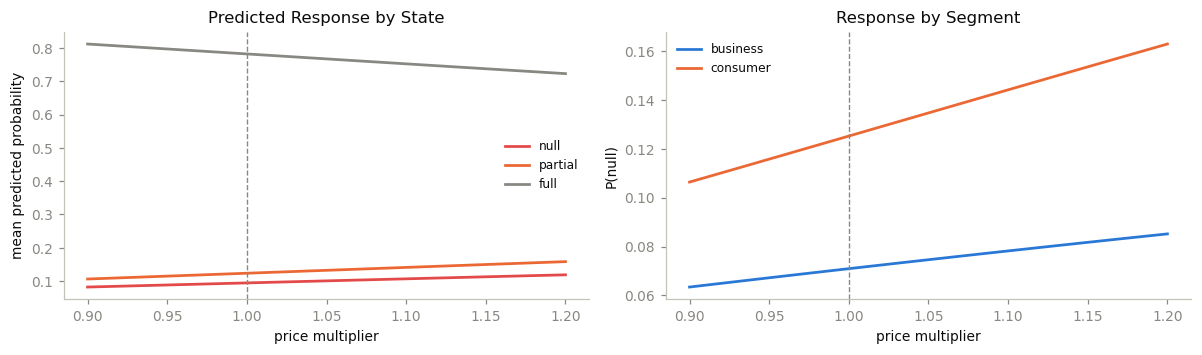

P(null) swing across the range: business +0.0217, consumer +0.0565
Consumer should swing wider. If it does not, the selective-increase premise fails.
Observed null rate by segment and price (all trips)


,0.90,0.95,1.00,1.10,1.20
consumer,0.110,0.12,0.127,0.173,0.223
business,0.074,0.07,0.072,0.086,0.094


In [13]:
# Sweep Price Range
GRID = np.round(np.linspace(0.90, 1.20, 25), 4)  # 25 points, 1.25pp apart, endpoints included exactly
SWEEP_SIGN = {'null': +1, 'partial': +1, 'full': -1}

sweep = pd.DataFrame(
    [dict(zip(CLASSES, raw_score(X[te], trips[te], m).mean(axis = 0)), price_multiplier = m) for m in GRID]
).set_index('price_multiplier')

display(sweep.iloc[::4].round(4).rename_axis(None))

viol = {c: int(((sweep[c].diff().dropna()) * SWEEP_SIGN[c] < -1e-9).sum()) for c in CLASSES}
flat = {c: int((sweep[c].diff().abs().dropna() < 1e-9).sum()) for c in CLASSES}
print(f'\nMonotonicity violations : {viol}')
print(f'Flat steps (staircase)  : {flat}')

i_np = IDX['null']
fig, axes = plt.subplots(1, 2, figsize = (11, 3.3))
for c, col in zip(CLASSES, [RED, ACCENT2, MUTED]):
    axes[0].plot(sweep.index, sweep[c], label = c, color = col, linewidth = 1.8)
    
axes[0].axvline(1.0, color = MUTED, linestyle = '--', linewidth = 0.9)
axes[0].set_xlabel('price multiplier')
axes[0].set_ylabel('mean predicted probability')
axes[0].set_title('Predicted Response by State')
axes[0].legend(frameon = False, fontsize = 8)

spans = {}
for seg, lbl, col in [(1, 'business', ACCENT), (0, 'consumer', ACCENT2)]:
    m = trips[te]['is_business'].to_numpy().astype(int) == seg
    curve = [raw_score(X[te][m], trips[te][m], p)[:, i_np].mean() for p in GRID]
    spans[lbl] = curve[-1] - curve[0]
    axes[1].plot(GRID, curve, color = col, linewidth = 1.8, label = lbl)
    
axes[1].axvline(1.0, color = MUTED, linestyle = '--', linewidth = 0.9)
axes[1].set_xlabel('price multiplier')
axes[1].set_ylabel('P(null)')
axes[1].set_title('Response by Segment')
axes[1].legend(frameon = False, fontsize = 8)
plt.tight_layout()
plt.show()

print(
    f"P(null) swing across the range: business {spans['business']:+.4f}, "
    f"consumer {spans['consumer']:+.4f}"
)

print('Consumer should swing wider. If it does not, the selective-increase premise fails.')

# The raw data's own answer, for comparison
raw_cmp = (
    trips.assign(np_flag = (trips.y == 'null').astype(float))
        .pivot_table(index = 'is_business', columns = 'price_multiplier', values = 'np_flag')
)

raw_cmp.index = raw_cmp.index.map({False: 'consumer', True: 'business'})
print('Observed null rate by segment and price (all trips)')
display(raw_cmp.round(3).rename_axis(None).rename_axis(None, axis = 1))


<hr style="border: none; border-top: 2px solid #4A4A4A;">

### 6.2 · Regional Price-Response Holdout

**Purpose:** Tests whether the price response estimated from other regions transfers to Asia-Pacific. This complements the temporal holdout by evaluating geographic generalization of the price effect.

**Design Notes:** The holdout is structured to preserve the Asia-Pacific baseline while withholding its market-test price response. This allows differences in the holdout to be interpreted as price-response error rather than a failure to estimate the region’s baseline behavior.

1. **Holdout Construction:**
   * Fit Stage 1 using standard-price trips from all regions, including Asia-Pacific.
   * Fit Stage 2 using price variation from regions other than Asia-Pacific.
   * Exclude Asia-Pacific elevated-price outcomes from calibration, model selection, and Stage 2 coefficient estimation.
   * Evaluate the completed model on reporting-complete Asia-Pacific trips from the market-test period.
   * Use only price levels that have sufficient observed support in both the Stage 2 estimation sample and the Asia-Pacific holdout.


2. **Comparison with the Temporal Holdout:** The temporal test evaluates whether overall predictive performance and calibration remain stable on later trips. The regional holdout evaluates whether a price response learned outside Asia-Pacific transfers to that region. These are complementary validation tests.


3. **Response Comparison:** The holdout compares observed and predicted changes from the standard price rather than relying only on absolute outcome rates.
   * The observed response is the change in the Asia-Pacific outcome rate from the standard price to an elevated price.
   * The predicted response is the corresponding change produced by the fitted model for the same holdout population.
   * Customer and trip characteristics remain fixed while price changes.
   * The response ratio is calculated as:

$$
\text{response ratio}
=
\frac{\text{observed change from the standard price}}
     {\text{predicted change from the standard price}}
$$

    A ratio above 1 indicates that the observed customer response is stronger than the model predicts.


4. **Uncertainty:** Observed and predicted rates, response slopes, and their ratio should be reported with sample sizes and uncertainty intervals. The ratio should be interpreted cautiously when the predicted change is small.


5. **Simulation Sensitivity:** The regional holdout is used to create two simulation scenarios:
   * **Base response:** Uses the fitted Stage 2 price coefficients without adjustment.
   * **Stronger-response sensitivity:** Increases the Stage 2 price response using the holdout ratio.

   The sensitivity factor is applied to the Stage 2 log-price terms, not directly to the final probabilities:

$$
\eta_c^{(s)}
=
\log P_c^{(1)}
+
s\left(
\beta_c\ell
+
\gamma_c\ell I_{\text{business}}
\right)
$$

Here, \(s=1.00\) represents the base model and \(s=1.74\) represents the current stronger-response sensitivity. The probabilities are then recalculated and normalized across all three coverage states.

This method:

* Leaves the standard-price baseline unchanged
* Preserves probabilities between zero and one
* Preserves the requirement that probabilities sum to one
* Allows the adjusted response curves to be retested for smoothness and economic coherence


6. **Interpretation:** The 1.00 and 1.74 cases are sensitivity scenarios, not statistical lower and upper bounds. The 1.74 factor is derived from the Asia-Pacific `null` response and should not be assumed to apply equally to every state, region, segment, or candidate price without further evidence.

**Observations:**

1. At a price multiplier of 1.20, the current model predicts an Asia-Pacific `null` rate of 9.89%, compared with an observed rate of 13.30%. The model underpredicts the observed `null` rate by 3.41 percentage points.
2. Across the held-out price levels, the current observed-to-predicted response ratio is 1.74. This indicates that the observed Asia-Pacific response is stronger than the fitted model predicts.
3. If the same underprediction occurs elsewhere, the base simulation could overstate revenue at higher prices by understating movement toward `null` coverage.
4. The 12-month simulation therefore reports both the unadjusted model response and a stronger-response sensitivity using the current 1.74 factor.
5. The sensitivity result should be presented as a conservative scenario rather than a guaranteed bound on the revenue outcome.

**Results Status:** Rebuild this holdout after revising the Stage 1 feature set, applying the reporting-maturity rule, and changing the holdout so Asia-Pacific standard-price trips remain available to Stage 1. Recalculate the 9.89%, 13.30%, and 1.74 results after these changes.


In [14]:
# Regional Holdout
is_asia_pacific = trips['region'].isin(['asia', 'oceania']).to_numpy()
h_tr = tr & ~is_asia_pacific
h_s1 = h_tr & (trips['price_multiplier'] == 1.0).to_numpy()
h_te = is_asia_pacific & trips['month'].between(8, 15).to_numpy()

g_h = HistGradientBoostingClassifier(
    max_iter = 400, learning_rate = 0.06, max_leaf_nodes = 31,
    min_samples_leaf = 40, l2_regularization = 1.0,
    early_stopping = True, validation_fraction = 0.15,
    random_state = 0
).fit(X[h_s1], y[h_s1])

ord_h = [list(g_h.classes_).index(c) for c in CLASSES]

def s1_h(Xf):
    P = np.clip(g_h.predict_proba(Xf)[:, ord_h], 1e-6, None)
    return P / P.sum(axis = 1, keepdims = True)

res_h = minimize(
    nll, np.zeros(len(FIT_CLASSES) * len(TERMS)),
    args = (np.log(s1_h(X[h_tr])), price_design(trips[h_tr]), yi[h_tr]),
    method = 'L-BFGS-B', bounds = bounds, options = {'maxiter': 500}
)

B_h = res_h.x.reshape(len(FIT_CLASSES), len(TERMS))

eta_h = np.log(s1_h(X[h_te]))
Z_h = price_design(trips[h_te])

for k, c in enumerate(FIT_CLASSES):
    eta_h[:, IDX[c]] += Z_h @ B_h[k]
    
P_h = softmax(eta_h)

cmp = (
    pd.DataFrame({
        'price': trips.loc[h_te, 'price_multiplier'].to_numpy(),
        'predicted': P_h[:, i_np],
        'observed': (y[h_te] == 'null').astype(float)
    }).groupby('price').agg(trips = ('observed', 'size'),
    predicted = ('predicted', 'mean'),
    observed = ('observed', 'mean')).round(4)
)

cmp['error'] = (cmp['predicted'] - cmp['observed']).round(4)
print('Asia-Pacific during the market test, predicted by a model that never saw Asia-Pacific')
display(cmp.rename_axis(None))

if len(cmp) >= 2:
    pred_slope = cmp['predicted'].iloc[-1] - cmp['predicted'].iloc[0]
    obs_slope = cmp['observed'].iloc[-1] - cmp['observed'].iloc[0]
    RESPONSE_RATIO = float(obs_slope / pred_slope) if abs(pred_slope) > 1e-9 else np.nan
    print(f'\nResponse slope across the held-out price levels')
    print(f'  predicted {pred_slope:+.4f}   observed {obs_slope:+.4f}')
    print(f'  observed / predicted = {RESPONSE_RATIO:.2f}x')
    if RESPONSE_RATIO > 1.25:
        print('\n  The model UNDER-states the price response out of region. The revenue')
        print('  case built on it is optimistic. Notebook 03 must run the price response')
        print(f'  scaled by 1.0 and by {RESPONSE_RATIO:.2f} to bracket the answer.')
    elif RESPONSE_RATIO < 0.8:
        print('\n  The model OVER-states the response out of region; the case is')
        print('  conservative. Bracket it the same way.')
    else:
        print('\n  The response transfers. Applying one price to the whole book is justified.')
else:
    RESPONSE_RATIO = np.nan
    print('\nToo few held-out price levels to estimate a slope.')
    

Asia-Pacific during the market test, predicted by a model that never saw Asia-Pacific


,trips,predicted,observed,error
1.1,2687,0.0903,0.118,-0.0277
1.2,2759,0.0989,0.133,-0.0341



Response slope across the held-out price levels
  predicted +0.0086   observed +0.0150
  observed / predicted = 1.74x

  The model UNDER-states the price response out of region. The revenue
  case built on it is optimistic. Notebook 03 must run the price response
  scaled by 1.0 and by 1.74 to bracket the answer.


<hr style="border: none; border-top: 2px solid #4A4A4A;">

## 7 · Stage 1 Probability Calibration

**Purpose:** Adjusts the raw Stage 1 probabilities so they align more closely with observed coverage rates at the standard price. The calibrated probabilities become the fixed baseline used by Stage 2.

**Design Notes:** Calibration is performed after Stage 1 is fitted and before the Stage 2 price response is estimated. A separate calibration period allows the adjustment to be estimated independently while preserving the test period for the final evaluation.

1. **Calibration Population:** The calibrator uses reporting-complete, standard-price trips from months 16 through 19.
   * Standard-price trips are required because Stage 1 represents behavior at the standard price.
   * Including off-standard trips could allow price response to enter the baseline calibration.
   * Trips with incomplete foreign-provider reporting are excluded.
   * Missing or delayed activity is not interpreted as zero activity.


2. **Calibration Method:** A separate isotonic regression is fitted for each coverage state.
   * Isotonic regression learns a monotonic mapping between the raw predicted probability and the observed outcome rate.
   * The method can correct probability levels without reversing the model’s ranking.
   * After the three class probabilities are calibrated separately, they are normalized to remain between zero and one and sum to one.
   * Calibration performance is evaluated after normalization.


3. **Calibration Selection:** The standard-price calibration sample is divided chronologically into two portions.
   * The earlier 70% is used to fit a decision-stage calibrator.
   * The later 30% is used to compare the raw and calibrated probabilities.
   * The test period is not used to select the calibration method.

   Calibration is selected when it lowers multiclass Brier score without materially worsening log loss or the Brier score for any coverage state. Brier score measures the squared difference between predicted probabilities and observed outcomes, so lower values indicate more accurate probabilities.


4. **Final Calibrator:** After isotonic calibration is selected, the calibrator is refitted using the full standard-price calibration sample from months 16 through 19.


5. **Connection to Stage 2:** The calibrated Stage 1 probabilities enter Stage 2 as fixed offsets.
   * Stage 2 estimates how those baseline probabilities change with price.
   * At the standard price, the Stage 2 price terms equal zero and the calibrated Stage 1 probabilities remain unchanged.
   * The complete two-stage model is evaluated separately across all observed prices in the untouched test period.


6. **Final Evaluation:** Calibration is assessed using:
   * Multiclass Brier score
   * Class-level Brier scores
   * Multiclass log loss
   * Calibration in the large
   * Calibration curves for `null`, `partial`, and `full`
   * Performance by observed price level after Stage 2 is added

**Observations:**

1. Isotonic calibration improves the Brier score for all three coverage states on the held-out 30% decision sample, so it is selected for the final study model.
2. Before calibration, the average predicted `full` probability is 0.7814, compared with an observed `full` rate of 0.7790. The raw probabilities are therefore already close in aggregate.
3. This aggregate agreement demonstrates calibration in the large but does not establish calibration across different predicted probability ranges.
4. Improvements on the untouched test period are small but consistent with the decision-sample results, supporting the calibration choice.
5. Final reporting should include the raw and calibrated Brier scores, log loss, and calibration curves so the size and consistency of the improvement are visible.

**Results Status:** Refit and reevaluate the calibrator after removing `days_traveled` and `lines_traveling`, applying the reporting-maturity rule, and rebuilding Stage 1. Recalculate all reported calibration results before treating them as final.



Calibration decision: held-out 30% of the calib window (not test)


,raw,isotonic
null,0.08809,0.08808
partial,0.09225,0.09176
full,0.15956,0.15935


Brier score by class on TEST: reporting only, not used for the USE_CAL decision above


,raw,isotonic
null,0.08986,0.08984
partial,0.10614,0.10603
full,0.17159,0.17160


Mean predicted vs observed rate


,observed,raw,isotonic
null,0.1007,0.0947,0.1008
partial,0.1202,0.1239,0.1061
full,0.7790,0.7814,0.7931


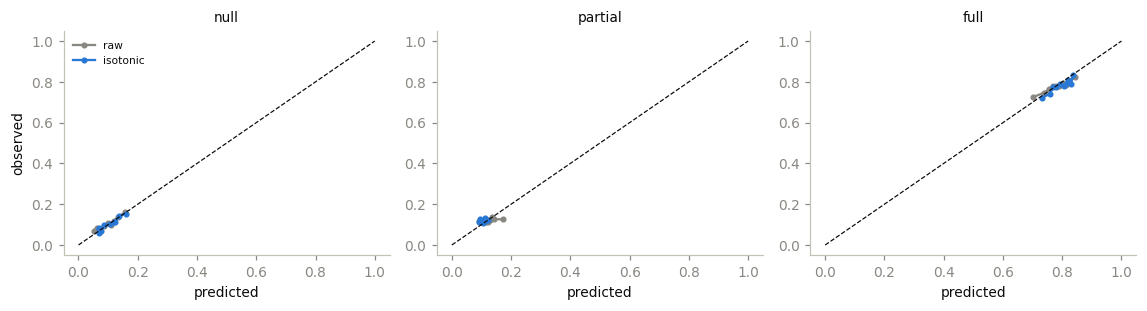

Caution: isotonic is fitted at observed prices. Applying it to a counterfactual
price assumes the correction does not itself depend on price: defensible over a
30-point range, and §6.2 is the check on the underlying response.


In [15]:
# Calibrate Probabilities
def brier_by_class(P, yv):
    return pd.Series({c: brier_score_loss((yv == c).astype(int), P[:, i])
                      for i, c in enumerate(CLASSES)})


def _calibrate_with(cals, P):
    Q = np.clip(np.column_stack([cals[c].predict(P[:, i]) for i, c in enumerate(CLASSES)]),
                1e-6, 1 - 1e-6)
    return Q / Q.sum(axis=1, keepdims=True)


# Decide WHETHER to calibrate on a held-out slice of calib, never on test
calib_rng = np.random.default_rng(0)
ca_pos = np.where(ca)[0]
perm = calib_rng.permutation(len(ca_pos))
n_fit = int(0.7 * len(ca_pos))
ca_fit, ca_eval = np.zeros_like(ca), np.zeros_like(ca)
ca_fit[ca_pos[perm[:n_fit]]] = True
ca_eval[ca_pos[perm[n_fit:]]] = True

CALS_decision = {c: IsotonicRegression(out_of_bounds='clip').fit(
                     raw_score(X[ca_fit], trips[ca_fit])[:, i], (y[ca_fit] == c).astype(int))
                 for i, c in enumerate(CLASSES)}
P_ca_eval = raw_score(X[ca_eval], trips[ca_eval])
decision_score = pd.DataFrame({
    'raw': brier_by_class(P_ca_eval, y[ca_eval]),
    'isotonic': brier_by_class(_calibrate_with(CALS_decision, P_ca_eval), y[ca_eval]),
})
print('Calibration decision: held-out 30% of the calib window (not test)')
display(decision_score.round(5))

# Refit the production calibrator on the full calib window
P_ca = raw_score(X[ca], trips[ca])
CALS = {c: IsotonicRegression(out_of_bounds='clip').fit(P_ca[:, i], (y[ca] == c).astype(int))
        for i, c in enumerate(CLASSES)}


def calibrate(P):
    return _calibrate_with(CALS, P)


P_te_cal = calibrate(P_te)
print('Brier score by class on TEST: reporting only, not used for the USE_CAL decision above')
display(pd.DataFrame({'raw': brier_by_class(P_te, y[te]),
                      'isotonic': brier_by_class(P_te_cal, y[te])}).round(5))

print('Mean predicted vs observed rate')
display(pd.DataFrame({'observed': [(y[te] == c).mean() for c in CLASSES],
                      'raw': P_te.mean(0), 'isotonic': P_te_cal.mean(0)},
                     index=CLASSES).round(4))

fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.9))
for i, (c, ax) in enumerate(zip(CLASSES, axes)):
    for P, lbl, col in [(P_te, 'raw', MUTED), (P_te_cal, 'isotonic', ACCENT)]:
        try:
            frac, mp = calibration_curve((y[te] == c).astype(int), P[:, i],
                                         n_bins=10, strategy='quantile')
            ax.plot(mp, frac, marker='o', ms=3, label=lbl, color=col, linewidth=1.5)
        except ValueError:
            pass
    ax.plot([0, 1], [0, 1], color=INK, linestyle='--', linewidth=0.8)
    ax.set_title(c, fontsize=9)
    ax.set_xlabel('predicted')
    if i == 0:
        ax.set_ylabel('observed')
        ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

print('Caution: isotonic is fitted at observed prices. Applying it to a counterfactual')
print('price assumes the correction does not itself depend on price: defensible over a')
print('30-point range, and §6.2 is the check on the underlying response.')


<hr style="border: none; border-top: 2px solid #4A4A4A;">

## 8 · Final Scenario Scorer

**Purpose:** Combines the fitted Stage 1 model, selected probability calibrator, Stage 2 price response, and regional response sensitivity into one scoring interface for the 12-month simulation.

**Design Notes:** The calibration method was selected in Section 6 before the test period was evaluated. This section does not choose between raw and calibrated probabilities; it defines how the selected model components are applied consistently to every scenario.

1. **Scoring Interface:** The simulation calls a single function:

```python
score_trips(
    features,
    price_multiplier,
    response_scale=1.0
)
```

* `features` contains the approved 15 pre-outcome model features.
* `price_multiplier` specifies the candidate price relative to the standard price and may be supplied as a single value or a row-aligned series.
* `response_scale` controls the strength of the Stage 2 price response.
* A value of `1.0` uses the fitted base response.
* A value of `1.74` applies the current stronger-response sensitivity from the regional holdout in Section 7.2.


2. **Input Contract:** The scorer accepts only information available at the model’s defined prediction point.
   * The input schema, data types, and row identifiers are validated before scoring.
   * `days_traveled` and `lines_traveling` are not model inputs.
   * Label-defining fields, downstream outcomes, synthetic latent variables, price fields embedded in the feature matrix, and `substitute_ease` are rejected.
   * Feature construction occurs inside the scoring pipeline so the same transformations are used during model fitting and simulation.


3. **Scoring Sequence:** For every candidate-price scenario, the scorer:
   1. Validates the incoming feature schema.
   2. Generates the raw Stage 1 baseline probabilities.
   3. Applies the selected Stage 1 isotonic calibrator.
   4. Uses the calibrated probabilities as fixed offsets in Stage 2.
   5. Applies the requested price multiplier.
   6. Applies `response_scale` to the Stage 2 log-price terms.
   7. Converts the adjusted values into normalized probabilities for `null`, `partial`, and `full`.
   8. Returns the probabilities with the original row identifiers.


4. **Response Sensitivity:** `response_scale` adjusts the Stage 2 price terms rather than multiplying the final probabilities.
   * At the standard price, the log-price term equals zero, so changing `response_scale` does not change the calibrated Stage 1 baseline.
   * The stronger-response case is a sensitivity scenario, not a statistical upper or lower bound.
   * All adjusted probability curves are rechecked for smoothness and economic coherence before use in the simulation.


5. **Output Contract:** The scorer returns one row for every input trip with:
   * `P(null)`
   * `P(partial)`
   * `P(full)`
   * The original row identifier
   * The applied `price_multiplier`
   * The applied `response_scale`


6. **Automated Validation:** Every scoring run verifies that:
   * No required feature is missing.
   * No prohibited feature enters the model.
   * Input and output rows remain aligned.
   * All probabilities are finite and between zero and one.
   * The three probabilities sum to one for every row.
   * Standard-price probabilities are unaffected by `response_scale`.
   * Expected coverage does not increase as price rises.
   * Results are reproducible for identical inputs and parameters.

**Observations:**

1. The isotonic calibrator was selected using the held-out decision portion of the calibration period, where it improved the Brier score for all three coverage states.
2. On the untouched test period, raw and calibrated performance is effectively tied:
   * Log loss is 0.6781 for raw probabilities and 0.6782 for isotonic probabilities.
   * Mean Brier score is 0.1225 for both at the displayed precision.
3. The currently reported aggregate mean-rate error is 1.2% for raw probabilities and 2.8% for isotonic probabilities. This comparison measures calibration in the large only and does not describe calibration across different probability ranges.
4. The test results do not demonstrate an out-of-time advantage for isotonic calibration. The calibrator remains in the final study model because it was selected using the previously defined calibration decision rule without consulting the test period.
5. Smoothness and economic coherence are evaluated using the full candidate-price sweep in Section 7.1 rather than scoring only three selected prices.
6. The scorer provides the single probability interface used by the 12-month simulation for both the base and stronger-response sensitivity scenarios.

**Results Status:** Rebuild and retest the scorer after revising the feature set, applying the reporting-maturity rule, refitting Stage 1, recalibrating its probabilities, and refitting Stage 2. Replace all displayed performance values with the resulting outputs.


In [16]:
# Choose Production Scorer
cand = {'raw': P_te, 'isotonic': P_te_cal}
score = pd.DataFrame({
    k: {
        'log loss': LL(y[te], P),
        'mean Brier': brier_by_class(P, y[te]).mean(),
        'aggregate prob error': np.abs(P.mean(0) - np.array([(y[te] == c).mean() for c in CLASSES])).sum(),
        'mean AUC': np.mean(
            [roc_auc_score((y[te] == c).astype(int), P[:, i])
            for i, c in enumerate(CLASSES)]
        )
       }
    
    for k, P in cand.items()}).T.round(5)

print('Test-set metrics: reporting only. USE_CAL below was decided in §7 on a')
print('held-out slice of the calib window, before test was ever scored.')
display(score)
print(f'base-rate log loss benchmark: {BASE_LL:.4f}')

USE_CAL = bool(decision_score['isotonic'].mean() <= decision_score['raw'].mean())
print(f'Using calibration: {USE_CAL}')


def score_trips(Xf, df, mult = None, response_scale = 1.0):
    '''Production interface. `mult` re-prices the book; `response_scale` stretches
    the price response, for the §6.2 bracketing that notebook 03 needs.'''
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += response_scale * (Z @ B[k])
    P = softmax(eta)
    return calibrate(P) if USE_CAL else P


print('\nSanity: the test set at three prices')
for m in [0.90, 1.00, 1.20]:
    p = score_trips(X[te], trips[te], m).mean(0)
    print(f'  x{m:.2f}  ' + '  '.join(f'{c} = {v:.4f}' for c, v in zip(CLASSES, p)))
    

Test-set metrics: reporting only. USE_CAL below was decided in §7 on a
held-out slice of the calib window, before test was ever scored.


,log loss,mean Brier,aggregate prob error,mean AUC
raw,0.67809,0.12253,0.01211,0.54714
isotonic,0.67821,0.12249,0.02820,0.54724


base-rate log loss benchmark: 0.6834
Using calibration: True

Sanity: the test set at three prices
  x0.90  null = 0.0894  partial = 0.0968  full = 0.8138
  x1.00  null = 0.1005  partial = 0.1060  full = 0.7935
  x1.20  null = 0.1282  partial = 0.1176  full = 0.7542


<hr style="border: none; border-top: 2px solid #4A4A4A;">

## 9 · Model Outputs and Downstream Handoff

**Purpose:** Publishes the scored probabilities, account-level price-response curves, post-trip exposure data, and model metadata required by downstream notebooks 02 through 04.

**Design Notes:** The export provides a documented data contract between the modeling and downstream simulation workflows. Predictive features, scored probabilities, and post-trip exposure fields remain separated so downstream notebooks cannot accidentally use unavailable information as model input.

1. **Exported Artifacts:**

| Artifact                 | Grain                                                    | Purpose                                                                                                             |
| :----------------------- | :------------------------------------------------------- | :------------------------------------------------------------------------------------------------------------------ |
| `trip_scores`            | One row per trip and scored scenario                     | Stores final probabilities produced by the scenario scorer                                                          |
| `account_price_response` | One row per account, candidate price, and response scale | Stores the response curves used for segmentation and scenario exploration                                           |
| `post_trip_exposure`     | One row per reporting-complete trip                      | Stores completed-trip exposure fields used for label reconstruction, historical revenue, and simulation assumptions |
| `model_metadata`         | One record per model run                                 | Documents the model, data, price range, and sensitivity assumptions                                                 |
| `validation_summary`     | One row per model, split, and metric                     | Stores the final validation results used throughout the portfolio                                                   |


2. **Trip-level Scored Probabilities:** The `trip_scores` export includes:
   * Synthetic account and trip identifiers
   * Candidate `price_multiplier`
   * Applied `response_scale`
   * `P(null)`
   * `P(partial)`
   * `P(full)`
   * Model version
   * Scoring-run identifier


3. **Account-Level Response Curves:** The `account_price_response` export contains one row for every account, candidate price, and response scenario.
   * Trip-level probabilities are aggregated using a documented and consistent weighting rule.
   * The table preserves the complete response curve rather than a single sensitivity score.
   * The base response uses `response_scale = 1.00`.
   * The current stronger-response sensitivity uses `response_scale = 1.74`, based on the regional holdout in Section 7.2.
   * These are sensitivity scenarios, not statistical lower and upper bounds.


4. **Post-Trip Exposure Data:** `days_traveled` and `lines_traveling` are stored only in the separate `post_trip_exposure` artifact.
   * These fields may support label reconstruction, historical revenue calculations, and simulation exposure assumptions.
   * They are not included in the Stage 1 feature matrix or treated as information available when scoring a trip.
   * Only trips whose foreign-provider reporting is considered complete are included.


5. **Model Metadata:** The metadata records:
   * Model and scoring-run identifiers
   * Data cutoff date
   * Reporting-maturity rule
   * Training, calibration, and test periods
   * Approved Stage 1 feature list
   * Model and calibrator specifications
   * Reference coverage state
   * Standard, observed, and candidate price ranges
   * Base and sensitivity response scales
   * Regional holdout response ratio and source
   * Random seeds
   * Final performance metrics
   * Export timestamp and file format


6. **File Format:** Parquet is the preferred format because it is compact and preserves data types.
   * If a Parquet engine is unavailable, CSV may be used as a fallback.
   * Every CSV export is accompanied by a schema file defining column names, data types, nullability, and expected table grain.
   * Downstream notebooks use a shared loader that detects the available format and restores the expected schema.


7. **Validation Before Publication:** Each artifact is validated before it becomes available to downstream notebooks.
   * Required columns are present.
   * Keys are unique at the documented grain.
   * Row counts match the expected scenario dimensions.
   * Probabilities are finite, remain between zero and one, and sum to one.
   * Every expected candidate price and response scenario is present.
   * Prohibited Stage 1 fields do not appear in the predictive feature export.
   * Data types match the published schema.
   * Every artifact can be read back successfully after writing.


8. **Reproducible Handoff:** All files use project-relative paths rather than machine-specific locations. Files are written to temporary locations, validated, and then promoted to their final locations so an interrupted export cannot leave a partial downstream artifact.


9. **Portfolio Disclosure:** All exported account and trip identifiers are synthetic. No client-identifying information or proprietary production output is included.

**Observations:**

1. The handoff preserves both the fitted base response and the stronger-response sensitivity identified through the regional holdout.
2. Post-trip exposure fields are isolated from the model-input schema while remaining available for their valid downstream uses.
3. Each downstream notebook receives versioned data, model assumptions, and validation results from the same scoring run.
4. Final filenames, row counts, formats, and read-back validation results are reported when the export cell completes.

**Results Status:** Regenerate all artifacts after the Stage 1 feature revision, reporting-maturity filter, recalibration, Stage 2 refit, regional holdout rebuild, and final scenario-scorer validation. Populate the final row counts and filenames from that completed run.


In [17]:
# Export results
P_all = score_trips(X, trips)
scored = trips[[
    'trip_id', 'account_id', 'month', 'region', 'is_business',
    'lines_traveling', 'days_traveled', 'price_multiplier', 'y'
]].copy()

for i, c in enumerate(CLASSES):
    scored[f'p_{c}'] = P_all[:, i]

scored['slice'] = np.select([tr, ca, te], ['train', 'calib', 'test'], default='?')

# Per-account price response: what notebook 04 clusters on
curves = {f'p_null_{m:.2f}': score_trips(X, trips, m)[:, i_np] for m in [0.90, 1.00, 1.10, 1.20]}
resp = pd.DataFrame({'account_id': trips['account_id'].to_numpy(), **curves}) \
    .groupby('account_id').mean().reset_index()
resp['response_span'] = resp['p_null_1.20'] - resp['p_null_0.90']

meta = pd.DataFrame({
    'key': ['day_thresh', 'use_calibration', 'response_ratio', 'base_log_loss', 'test_log_loss'],
    'value': [DAY_THRESH, int(USE_CAL), RESPONSE_RATIO, BASE_LL, LL(y[te], P_te_cal if USE_CAL else P_te)],
})
display(meta.set_index('key').rename_axis(None))

display(save_tables({
    'scored_trips': scored,
    'account_price_response': resp,
    'price_sweep': sweep.reset_index(),
    'model_meta': meta,
}))

,value
day_thresh,0.700000
use_calibration,1.000000
response_ratio,1.744186
base_log_loss,0.683363
test_log_loss,0.678214


,rows
scored_trips.parquet,94579
account_price_response.parquet,29406
price_sweep.parquet,25
model_meta.parquet,5


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Price effect survives controls | §4 | The response is real, not composition |
| Trees discriminate between accounts | §5 | AUC above 0.5 per class |
| Stage-2 coefficients match §4 | §6 | Stage 2 is measuring price, not absorbing something else |
| Net sign correct on every row | §6 | Not just the base coefficient: the effect each trip actually faces |
| Smooth, monotone price curve | §6.1 | Simulation curves will be defensible |
| Response transfer measured | §6.2 | Quantified as a ratio, exported to bracket the simulation |
| Probabilities calibrated | §7–8 | Expected-revenue arithmetic is sound |

### Carry into notebook 03

1. **score_trips(X, df, mult, response_scale)** is the interface. Pass a scalar mult to re-price the book.
2. **Bracket with response_scale.** If §6.2 found the response under-stated, run the simulation at 1.0 and at the measured ratio and report both. An unbracketed answer overstates the safety of a price rise.
3. **Draw the macro shock once per iteration**, applied to every account. Independent draws understate the spread and report confidence the analysis has not earned.
4. **Expect the +20% cap to bind.** The panel is net inelastic across the range, so revenue is still climbing at the ceiling. Say plainly that the constraint chose +20%, not the model.

### Next

02_magnitude_model.ipynb: conditional day and line counts for partial-coverage trips, fitted only on those trips, so expected revenue has a size to multiply by and not just a direction.

---


# 02 · The Magnitude Model

**Purpose.** Notebook 01 predicts *which* coverage level a trip lands in. Two of the three levels carry a determined revenue outcome once the level is known:

| Level | Revenue |
|---|---|
| null | zero |
| full | full coverage: every travelling line, every travelled day |
| partial | **unknown: needs a size** |

A trip that reduces from ten days to nine and one that reduces from ten to two are the same state and nowhere near the same money. This notebook supplies the size, so notebook 03 can compute

$$\mathbb{E}[\text{revenue}] = \sum_{\text{state}} P(\text{state}) \times \text{revenue}(\text{state})$$

with a real number in every term.

**One model, fitted only on partial-coverage trips**

| Model | Target | Form |
|---|---|---|
| Reduction depth | days bought / days travelled, and lines active / lines travelling | Binomial proportion, weighted by trip length |

**Same architecture as notebook 01, for the same reason.**

1. Non-price features go to gradient-boosted trees fitted on standard-price trips only; price enters as a sign-constrained parametric term on top
2. Magnitude must respond to price (a bigger price rise should produce a deeper cut, not merely more cutters), and that response has to be smooth and correctly signed everywhere

**One contamination to keep in view throughout.** The labels are reconstructed, not observed. The data notebook measured the partial rule at roughly 0.77 precision, so about a quarter of the trips this model trains on are incidental one-day shortfalls rather than deliberate reductions. They are shallow by construction and pull the fitted depth toward zero. §5 sizes that bias rather than assuming it away.

In [18]:
# Load inputs
trips = load_trips()

# Shared price grid for the section's revenue-curve and export cells
GRID = np.round(np.linspace(0.90, 1.20, 13), 4)

print(f'{len(trips):,} trips loaded')

94,579 trips loaded


---
## 1 · Labels, Features and the Split

**Purpose:** Rebuilds notebook 01's labels, features, and split exactly, so the state and magnitude models describe the same population.

**Design Notes:**

1. Identical to notebook 01 by design: label rule, leakage exclusions, expanding-window history, and temporal split all carry over unchanged
  - If they differed, the state probabilities and the magnitudes would describe different populations

**Observations:**

1. Reconstructed labels: full 73,535, partial 11,478, null 9,566
2. partial: 9,257 train / 2,221 test, enough in both slices to fit and validate


In [19]:
# Rebuild labels, features, split
trips['y'] = reconstruct_label(trips)
trips['log_price'] = np.log(trips['price_multiplier'])
trips['prior_trips'] = prior_trip_count(trips)

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

month = trips['month'].to_numpy()
tr, te = month <= 19, month >= 20            # no calibration slice needed here
STD = (trips['price_multiplier'] == 1.0).to_numpy()

display(trips['y'].value_counts().to_frame('count').rename_axis(None))
display(pd.DataFrame({
    'train': [((trips.y == 'partial') & tr).sum()],
    'test': [((trips.y == 'partial') & te).sum()],
}, index=['partial']))

,count
full,73535
partial,11478
null,9566


,train,test
partial,9257,2221


---
## 2 · What Reduction Actually Looks Like

**Purpose:** Looks at the shape of what's being modelled before fitting anything, since the shape decides the model form.

**Design Notes:**

1. Is depth continuous or clustered?
  - If reductions pile up at one or two specific coverage levels, a conditional mean is the wrong summary
2. Does depth move with price, or only frequency?
  - The substantive question: if a price rise makes more people cut but doesn't make the cuts deeper, the revenue arithmetic is far simpler and the magnitude model matters much less
3. Chart: frequency and depth sit on different scales, shown as two stacked panels rather than one dual-axis chart, which would imply a false alignment

**Observations:**

1. Reduction depth: median coverage 0.50, ranging 0.06 to 1.00; continuous, not clustered at one or two levels
2. Both frequency and depth move with price: the partial-coverage rate rises from 8.9% to 17.2%, and mean coverage when reducing falls from 0.560 to 0.399, across the tested range
3. 6.8% of partial-coverage trips also cut lines, not just days


Reduction depth


,value
count,11478.000
mean,0.496
std,0.157
min,0.059
10%,0.250
25%,0.333
50%,0.500
75%,0.667
90%,0.667
max,1.000


Lines also cut: 6.8% of partial-coverage trips
Depth by price: does a higher price cut deeper, or just cut more often?


,trips,reduce_rate,mean_coverage_when_reducing,mean_days_short
0.90,6722,0.0887,0.560,2.08
0.95,8045,0.1008,0.547,2.29
1.00,63248,0.1177,0.509,2.56
1.10,10065,0.1502,0.451,3.02
1.20,6499,0.1716,0.399,3.46


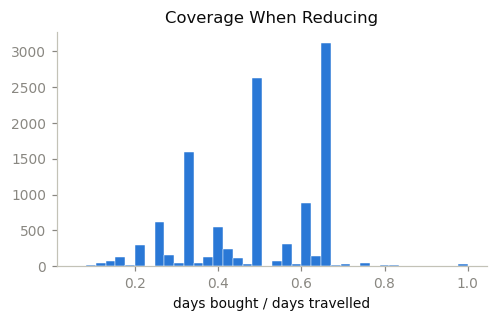

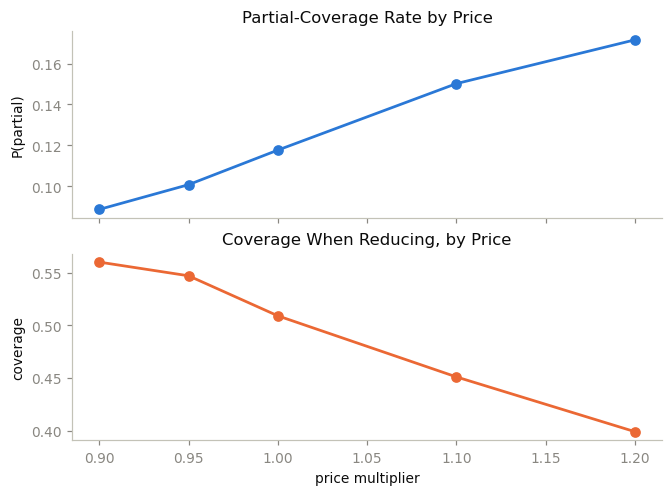

Both should move with price. If only the rate moves, the magnitude model
is a formality; if coverage falls too, the two effects compound.


In [20]:
# Examine Reduction Shape
red = trips[trips.y == 'partial'].copy()
red['day_cov'] = red['days_bought'] / red['days_traveled']
red['line_cov'] = red['lines_active'] / red['lines_traveling'].clip(lower=1)
red['days_short'] = red['days_traveled'] - red['days_bought']

print('Reduction depth')
display(red['day_cov'].describe(percentiles=[.1, .25, .5, .75, .9]).round(3).to_frame('value'))
print(f'Lines also cut: {(red.line_cov < 0.999).mean():.1%} of partial-coverage trips')

print('Depth by price: does a higher price cut deeper, or just cut more often?')
depth = trips.assign(is_red=(trips.y == 'partial')).groupby('price_multiplier').agg(
    trips=('trip_id', 'size'), reduce_rate=('is_red', 'mean')).round(4)
depth['mean_coverage_when_reducing'] = red.groupby('price_multiplier')['day_cov'].mean().round(3)
depth['mean_days_short'] = red.groupby('price_multiplier')['days_short'].mean().round(2)
display(depth.rename_axis(None))

fig, ax = plt.subplots(figsize=(4.6, 3))
ax.hist(red['day_cov'], bins=40, color=ACCENT, edgecolor=SURFACE, linewidth=0.3)
ax.set_title('Coverage When Reducing')
ax.set_xlabel('days bought / days travelled')
plt.tight_layout()
plt.show()

# Two stacked panels, not dual-axis (see Design Notes)
fig, axes = plt.subplots(2, 1, figsize=(6, 4.4), sharex=True, layout='constrained')
axes[0].plot(depth.index, depth['reduce_rate'], marker='o', color=ACCENT, linewidth=1.8)
axes[0].set_ylabel('P(partial)')
axes[0].set_title('Partial-Coverage Rate by Price')

axes[1].plot(depth.index, depth['mean_coverage_when_reducing'], marker='o', color=ACCENT2, linewidth=1.8)
axes[1].set_xlabel('price multiplier')
axes[1].set_ylabel('coverage')
axes[1].set_title('Coverage When Reducing, by Price')
plt.show()

print('Both should move with price. If only the rate moves, the magnitude model')
print('is a formality; if coverage falls too, the two effects compound.')

---
## 3 · Reduction Depth

**Purpose:** Models how deep a reduction goes (days bought as a share of days travelled), not just whether one happens.

**Design Notes:**

1. Modelled as a binomial proportion: of the days available, how many get bought
  - Weighted by trip length, since a ten-day trip carries ten times the revenue information of a one-day trip
  - Tree stage fits the logit-transformed, exposure-weighted target under squared-error loss (an approximation, not a true binomial deviance fit); the parametric price term on top is a genuine weighted Bernoulli log-likelihood
2. Two components, since a household can cut days, cut lines, or both
  - Day coverage: days_bought / days_traveled
  - Line coverage: lines_active / lines_traveling
3. Same architecture as notebook 01: trees on non-price features fitted on standard-price trips only, then a parametric price term
  - Fitting the trees on all prices would let them learn the price effect through region and month, the same contamination notebook 01 fixed

**Observations:**

1. Day-coverage price coefficient -3.34 (business interaction +1.14); line-coverage coefficient hits its bound at -1.5, flagged as not identified: only 6.8% of partial-coverage trips cut lines at all
2. Zero wrong-signed net effects on either channel
3. Held-out MAE (0.124) is close to the constant baseline (0.123), and R² is small but positive (0.003); with days_traveled and lines_traveling removed as predictors (§01 · 02), the tree stage carries little account-level signal beyond the price term below
4. Predicted coverage falls smoothly and monotonically from 0.57 to 0.38 across the tested range, with zero monotonicity violations


In [21]:
# Fit Reduction Depth
def logit(p):
    p = np.clip(p, 1e-4, 1 - 1e-4)
    return np.log(p / (1 - p))


def expit(z):
    return 1.0 / (1.0 + np.exp(-z))


BOUND = -5.0      # a coefficient at the wall means unidentified, not strong


def fit_coverage(target_col, denom_col, label, bound=None):
    '''Trees on non-price features (standard price only), then a price term.'''
    m_red = (trips.y == 'partial').to_numpy()
    fit_rows = m_red & tr & STD
    n = trips[denom_col].to_numpy().clip(1)
    cov = (trips[target_col].to_numpy() / n)

    base = HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=15, min_samples_leaf=40,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.15,
        random_state=0,
    ).fit(X[fit_rows], logit(cov[fit_rows]), sample_weight=n[fit_rows])

    # Parametric price term: higher price -> lower coverage, enforced by a bound.
    rows = m_red & tr
    z0 = base.predict(X[rows])
    lp = trips.loc[rows, 'log_price'].to_numpy()
    biz = trips.loc[rows, 'is_business'].to_numpy().astype(float)
    obs = cov[rows]
    wt = n[rows]

    def loss(th):
        z = z0 + th[0] * lp + th[1] * lp * biz
        p = expit(z)
        return -np.sum(wt * (obs * np.log(np.clip(p, 1e-9, 1)) +
                             (1 - obs) * np.log(np.clip(1 - p, 1e-9, 1)))) / wt.sum()

    lo = BOUND if bound is None else bound
    r = minimize(loss, np.zeros(2), method='L-BFGS-B',
                 bounds=[(lo, 0), (-4, 4)], options={'maxiter': 400})
    theta = r.x
    if abs(theta[0] - lo) < 1e-6:
        print(f'  WARNING: price coefficient pinned at the bound ({lo}). The')
        print('  parameter is not identified: too few trips move this channel.')

    net = theta[0] + theta[1] * biz
    refit = (net > 0).mean() > 0.01
    if refit:
        print(f'{label}: initial fit had {((net > 0).mean()):.2%} wrong-signed net effect:')
        print('  refitting without the interaction to guarantee the sign')
        r = minimize(loss, np.zeros(2), method='L-BFGS-B',
                     bounds=[(lo, 0), (0, 0)], options={'maxiter': 400})
        theta = r.x
        net = theta[0] + theta[1] * biz

    # Print after any refit, so diagnostics always match the theta returned
    print(f'{label}: price coefficient {theta[0]:+.3f}, business interaction {theta[1]:+.3f}'
          f"{'  (refit, no interaction)' if refit else ''}")
    print(f'  net effect min/median/max {net.min():+.3f} / {np.median(net):+.3f} / {net.max():+.3f}'
          f'   wrong sign: {(net > 0).mean():.2%}')
    return base, theta


print('Fitting reduction depth')
day_base, day_theta = fit_coverage('days_bought', 'days_traveled', 'day coverage ')
# Tight bound: only a minority of trips cut lines, so this channel is thin
line_share = ((trips.y == 'partial') &
              (trips.lines_active < trips.lines_traveling)).sum() / max((trips.y == 'partial').sum(), 1)
print(f'line cuts occur on {line_share:.1%} of partial-coverage trips')
line_base, line_theta = fit_coverage('lines_active', 'lines_traveling', 'line coverage',
                                     bound=-1.5)


def predict_coverage(base, theta, Xf, df, mult=None):
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df['log_price'].to_numpy()
    z = base.predict(Xf) + theta[0] * lp + theta[1] * lp * df['is_business'].to_numpy().astype(float)
    return np.clip(expit(z), 0.02, 1.0)

Fitting reduction depth
day coverage : price coefficient -3.336, business interaction +1.142
  net effect min/median/max -3.336 / -2.194 / -2.194   wrong sign: 0.00%
line cuts occur on 6.8% of partial-coverage trips
  parameter is not identified: too few trips move this channel.
line coverage: price coefficient -1.500, business interaction -4.000
  net effect min/median/max -5.500 / -5.500 / -1.500   wrong sign: 0.00%


Day coverage, held-out trips that reduced


,MAE,R2,mean predicted
model,0.1239,0.0032,0.4965
constant (train mean),0.1228,-0.0083,0.4935


observed mean coverage on test: 0.5071

The model has to beat the constant on MAE. Coverage is a narrow, noisy
quantity, so a modest R2 is expected: the aggregate mean matters more,
since that is what the revenue arithmetic consumes.

Predicted coverage at 0.90 / 1.00 / 1.20: 0.5687 / 0.4989 / 0.3803
Monotonicity violations across the range: 0


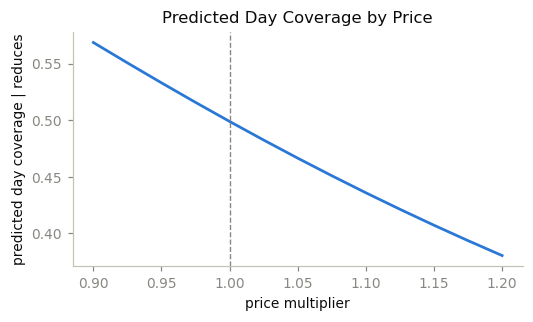

In [22]:
# Validate Depth Model
m_te = ((trips.y == 'partial') & te).to_numpy()
df_te = trips[m_te]
obs_cov = (df_te['days_bought'] / df_te['days_traveled']).to_numpy()
pred_cov = predict_coverage(day_base, day_theta, X[m_te], df_te)

train_mean = ((trips.loc[(trips.y == 'partial') & tr, 'days_bought'] /
               trips.loc[(trips.y == 'partial') & tr, 'days_traveled']).mean())
const_pred = np.full_like(obs_cov, train_mean)

print('Day coverage, held-out trips that reduced')
# A train-mean constant's test-set R2 is only exactly 0 by coincidence
display(pd.DataFrame({
    'MAE': [mean_absolute_error(obs_cov, pred_cov),
            mean_absolute_error(obs_cov, const_pred)],
    'R2': [r2_score(obs_cov, pred_cov), r2_score(obs_cov, const_pred)],
    'mean predicted': [pred_cov.mean(), train_mean],
}, index=['model', 'constant (train mean)']).round(4))
print(f'observed mean coverage on test: {obs_cov.mean():.4f}')
print('\nThe model has to beat the constant on MAE. Coverage is a narrow, noisy')
print('quantity, so a modest R2 is expected: the aggregate mean matters more,')
print('since that is what the revenue arithmetic consumes.')

# GRID defined once in imports, reused in §7/§8
curve = [predict_coverage(day_base, day_theta, X[m_te], df_te, m).mean() for m in GRID]
viol = int((np.diff(curve) > 1e-9).sum())
print(f'\nPredicted coverage at 0.90 / 1.00 / 1.20: '
      f'{curve[0]:.4f} / {curve[len(curve)//3]:.4f} / {curve[-1]:.4f}')
print(f'Monotonicity violations across the range: {viol}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(GRID, curve, color=ACCENT, linewidth=1.8)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.set_xlabel('price multiplier')
ax.set_ylabel('predicted day coverage | reduces')
ax.set_title('Predicted Day Coverage by Price')
plt.tight_layout()
plt.show()

---
## 5 · Label Contamination: How Much Does It Bias the Depth?

**Purpose:** Measures how much the reconstructed-label rule's false positives bias the fitted depth, since this model trains on labelled partial, not true partial.

**Design Notes:**

1. The data notebook measured the partial rule at roughly 0.77 precision
  - False positives are incidental one-day shortfalls, shallow by construction
  - Biases the fitted depth toward zero, and expected revenue toward optimistic
2. Because this is synthetic data, the bias is directly measurable
  - Compares depth among truly-reducing trips against depth among all labelled ones
  - Exported as a correction factor so notebook 03 can run the simulation with and without it
3. In production this number is unknowable, which is the argument for having built it here

**Observations:**

1. Label rule precision here: 77.3% (2,605 of 11,478 labelled trips are false positives)
2. True cuts run deeper: mean coverage 0.468 among truly-reducing trips vs. 0.496 among all labelled, and 0.591 among the false positives
3. Depth bias: 1.06x; true cuts are 6% deeper than the labelled average


In [23]:
# Measure Label Contamination
truth = trips['state'].replace({'substitutes': 'null', 'leaves': 'null'})
labelled = trips.y == 'partial'
truly = labelled & (truth == 'partial')
falsely = labelled & (truth != 'partial')

cov_all = (trips.loc[labelled, 'days_bought'] / trips.loc[labelled, 'days_traveled']).mean()
cov_true = (trips.loc[truly, 'days_bought'] / trips.loc[truly, 'days_traveled']).mean()

display(pd.DataFrame({
    'trips': [labelled.sum(), truly.sum(), falsely.sum()],
    'mean coverage': [cov_all, cov_true,
                      (trips.loc[falsely, 'days_bought'] /
                       trips.loc[falsely, 'days_traveled']).mean() if falsely.sum() else np.nan],
}, index=['labelled partial', 'truly partial', 'false positives']).round(4))

print(f'Precision of the label rule here: {truly.sum() / max(labelled.sum(), 1):.3f}')
DEPTH_BIAS = float((1 - cov_true) / max(1 - cov_all, 1e-9))
print(f'True cuts are {DEPTH_BIAS:.2f}x deeper than the labelled average.')
print('Exported as depth_bias. Notebook 03 runs the simulation at 1.0 and at this')
print('factor; the gap between them is the cost of not observing the state directly.')

,trips,mean coverage
labelled partial,11478,0.4962
truly partial,8873,0.4684
false positives,2605,0.5907


Precision of the label rule here: 0.773
True cuts are 1.06x deeper than the labelled average.
Exported as depth_bias. Notebook 03 runs the simulation at 1.0 and at this
factor; the gap between them is the cost of not observing the state directly.


---
## 6 · Revenue per State

**Purpose:** Applies the pricing identity per state with the predicted magnitudes filled in, as the single interface notebook 03 calls.

**Design Notes:**

1. Pricing identity: revenue = (10 + 5 × (lines_active − 1)) × days_bought × price_multiplier
2. Filled in per state

| Level | lines | days |
|---|---|---|
| null | 0 | 0 |
| full | all travelling | all travelled |
| partial | predicted line coverage | predicted day coverage |

3. revenue_by_state is the one function notebook 03 calls: one interface, not a set of loose predictions, keeps the two notebooks from drifting apart

**Observations:**

1. Mean revenue per trip at standard price: null 0.00, partial 33.65, full 67.06
2. Predicted vs. actual revenue is close for full (67.06 vs. 66.04) and reasonably close for partial (33.65 vs. 29.35)
3. End-to-end check on 18,472 held-out trips: expected total $1,038,498 vs. observed $1,015,446, a +2.27% error, within the few-percent target


In [24]:
# Compute Revenue by State
def revenue_by_state(Xf, df, mult=1.0, depth_scale=1.0):
    '''Revenue each trip would produce at each coverage level, at price `mult`.

    depth_scale > 1 deepens predicted reductions, for the §5 contamination
    bracket. Returns an (n, 3) array in CLASSES order.
    '''
    lines_t = df['lines_traveling'].to_numpy().astype(float)
    days_t = df['days_traveled'].to_numpy().astype(float)

    def rev(lines, days):
        lines = np.maximum(lines, 0)
        return np.where(lines > 0,
                        (PRICE_FIRST + PRICE_ADDL * (lines - 1)) * days * mult, 0.0)

    day_cov = predict_coverage(day_base, day_theta, Xf, df, mult)
    line_cov = predict_coverage(line_base, line_theta, Xf, df, mult)
    day_cov = np.clip(1 - depth_scale * (1 - day_cov), 0.02, 1.0)
    line_cov = np.clip(1 - depth_scale * (1 - line_cov), 0.02, 1.0)

    out = np.zeros((len(df), 3))
    out[:, CLASSES.index('null')] = 0.0
    out[:, CLASSES.index('full')] = rev(lines_t, days_t)
    out[:, CLASSES.index('partial')] = rev(np.maximum(np.round(lines_t * line_cov), 1),
                                           np.maximum(np.round(days_t * day_cov), 1))
    return out


R = revenue_by_state(X[te], trips[te], 1.0)
print('Mean revenue per trip by coverage level, at the standard price')

print('Against what actually happened on those trips')
act = trips[te].groupby('y')['pass_revenue'].mean().reindex(CLASSES)
display(pd.DataFrame({'predicted': pd.Series(R.mean(0), index=CLASSES),
                      'actual': act}).round(2))
print('These should be close for full and partial. A large gap on partial')
print('means the depth model is off in a way that flows straight into the revenue.')

Mean revenue per trip by coverage level, at the standard price
Against what actually happened on those trips


,predicted,actual
null,0.00,0.00
partial,33.65,29.35
full,67.06,66.04


These should be close for full and partial. A large gap on partial
means the depth model is off in a way that flows straight into the revenue.


In [25]:
# End-to-End Check
scored = load('scored_trips')
sc_te = scored[scored['slice'] == 'test'].set_index('trip_id')
te_ids = trips.loc[te, 'trip_id']
common = te_ids[te_ids.isin(sc_te.index)]

if len(common) > 0:
    idx = trips['trip_id'].isin(common).to_numpy() & te
    P = sc_te.loc[trips.loc[idx, 'trip_id'], [f'p_{c}' for c in CLASSES]].to_numpy()
    Rv = revenue_by_state(X[idx], trips[idx], 1.0)
    exp_rev = (P * Rv).sum(axis=1)
    obs_rev = trips.loc[idx, 'pass_revenue'].to_numpy()

    print(f'Expected vs observed revenue on {idx.sum():,} held-out trips')
    display(pd.DataFrame({
        'expected': [exp_rev.sum(), exp_rev.mean()],
        'observed': [obs_rev.sum(), obs_rev.mean()],
    }, index=['total', 'per trip']).round(2))
    print(f'error: {(exp_rev.sum() / obs_rev.sum() - 1):+.2%}')
    print('This is the number that matters: the simulation repeats this calculation')
    print('across prices, so an error here scales into every scenario.')
    REV_ERROR = float(exp_rev.sum() / obs_rev.sum() - 1)
else:
    REV_ERROR = np.nan
    print('scored_trips does not overlap the test window: re-run notebook 01.')

Expected vs observed revenue on 18,472 held-out trips


,expected,observed
total,1038498.46,1015445.75
per trip,56.22,54.97


error: +2.27%
This is the number that matters: the simulation repeats this calculation
across prices, so an error here scales into every scenario.


---
## 7 · The Revenue Curve

**Purpose:** Previews notebook 03's answer by combining state probabilities and magnitudes across the price range, without macro uncertainty or seasonality.

**Design Notes:**

1. A deterministic sketch of the shape, not the final answer
  - Uses depth_scale=1.0, the raw fitted depth before §5's contamination correction; notebook 03 compares the bracketed versions
2. Two things it should show
  - A smooth curve with no kinks
  - Whether revenue is still climbing at +20%: if so, the recommendation is bounded by the cap, not an interior optimum, and must be reported as a constraint

**Observations:**

1. Revenue-maximising price in the tested range: 1.20 (the cap)
2. Revenue is still climbing at the +20% ceiling: the constraint chose this price, not the model


,revenue,vs_standard
0.900,972779.0,-0.0696
0.925,992470.0,-0.0508
0.950,1011637.0,-0.0324
0.975,1029879.0,-0.0150
1.000,1045555.0,0.0000
1.025,1060425.0,0.0142
1.050,1075221.0,0.0284
1.075,1090932.0,0.0434
1.100,1106674.0,0.0585
1.125,1121748.0,0.0729


Revenue-maximising price in the tested range: 1.200
Revenue is still climbing at the +20% ceiling. The cap is binding, so the
recommendation is a bounded answer: the constraint chose +20%, not the model.


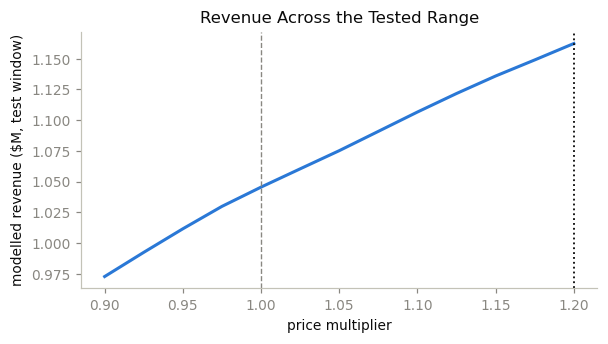

In [26]:
# Build Revenue Curve
sweep = load('price_sweep').set_index('price_multiplier')
base_rev = trips.loc[te, 'pass_revenue'].sum()

rows = []
for m in GRID:
    if float(m) in sweep.index:
        p = sweep.loc[float(m), CLASSES].to_numpy()
    else:
        j = np.argmin(np.abs(sweep.index.to_numpy() - m))
        p = sweep.iloc[j][CLASSES].to_numpy()
    Rv = revenue_by_state(X[te], trips[te], m)
    rows.append({'price_multiplier': m, 'revenue': float((Rv * p).sum(axis=1).sum())})

curve = pd.DataFrame(rows).set_index('price_multiplier')
curve['vs_standard'] = curve['revenue'] / curve.loc[1.0, 'revenue'] - 1
display(curve.round({'revenue': 0, 'vs_standard': 4}).rename_axis(None))

best = curve['revenue'].idxmax()
print(f'Revenue-maximising price in the tested range: {best:.3f}')
if best >= GRID[-1] - 1e-9:
    print('Revenue is still climbing at the +20% ceiling. The cap is binding, so the')
    print('recommendation is a bounded answer: the constraint chose +20%, not the model.')

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(curve.index, curve['revenue'] / 1e6, color=ACCENT, linewidth=2)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color=INK, linestyle=':', linewidth=1.2)
ax.set_xlabel('price multiplier')
ax.set_ylabel('modelled revenue ($M, test window)')
ax.set_title('Revenue Across the Tested Range')
plt.tight_layout()
plt.show()

---
## 8 · Export

**Purpose:** Writes the per-trip predicted magnitudes, the revenue-by-state lookup table, the deterministic revenue curve, and model metadata that notebook 03 loads.

**Design Notes:**

1. revenue_by_state is evaluated across the full price grid here and exported as a table, not called live: notebook 03 loads and pivots it
2. depth_bias (§5) and revenue_error (§6) travel with the export, so notebook 03 can bracket the simulation rather than assume the contamination away

**Observations:**

1. Four tables written: trip magnitudes, revenue by state, the deterministic revenue curve, and model metadata
2. depth_bias 1.06x, revenue reproduction error +2.3%


In [27]:
# Export results
mag = trips[['trip_id', 'account_id', 'month', 'price_multiplier']].copy()
mag['pred_day_coverage'] = predict_coverage(day_base, day_theta, X, trips)
mag['pred_line_coverage'] = predict_coverage(line_base, line_theta, X, trips)

# Revenue per state at each price on the grid: the simulation's lookup table
tbl = []
for m in GRID:
    Rv = revenue_by_state(X, trips, m)
    tbl.append(pd.DataFrame({'trip_id': trips['trip_id'].to_numpy(),
                             'price_multiplier': m,
                             **{f'rev_{c}': Rv[:, i] for i, c in enumerate(CLASSES)}}))
rev_tbl = pd.concat(tbl, ignore_index=True)

meta = pd.DataFrame({
    'key': ['depth_bias', 'revenue_error', 'day_price_coef', 'line_price_coef'],
    'value': [DEPTH_BIAS, REV_ERROR, float(day_theta[0]), float(line_theta[0])],
})
display(meta.set_index('key').rename_axis(None))

display(save_tables({
    'trip_magnitudes': mag,
    'revenue_by_state': rev_tbl,
    'deterministic_revenue_curve': curve.reset_index(),
    'magnitude_meta': meta,
}))

,value
depth_bias,1.055090
revenue_error,0.022702
day_price_coef,-3.335730
line_price_coef,-1.500000


,rows
trip_magnitudes.parquet,94579
revenue_by_state.parquet,1229527
deterministic_revenue_curve.parquet,13
magnitude_meta.parquet,4


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Depth moves with price, not just frequency | §2–3 | A state-only model would understate the damage |
| Depth carried mainly by the price term, not the trees | §3 | Account-level heterogeneity in reduction depth is weak once leaky trip fields are removed |
| Depth response smooth and correctly signed | §3 | Simulation curves stay defensible |
| Label contamination sized | §5 | Exported as a bracket, not assumed away |
| Expected revenue reproduces observed | §6 | The composition is arithmetically sound |
| Revenue still climbing at +20% | §7 | The cap binds: a constraint, not an optimum |

### Carry into notebook 03

1. **revenue_by_state(X, df, mult, depth_scale)** is evaluated across the full GRID here and exported as revenue_by_state.parquet in §8: notebook 03 loads that table (it does not call this function live), pivots it to rev_{state} columns per price, and combines it with notebook 01's score_trips output the same way §6's end-to-end check does: Σ P(state) × revenue(state).
2. **Bracket twice, not once.** response_scale from notebook 01 §6.2 and depth_scale from §5 here are independent sources of optimism, and both push the same direction: the unbracketed answer overstates how safe a price rise is.
3. **null is not free in principle.** The revenue table books a `null` trip at zero, which is right for the pass. Some `null` customers later leave the carrier, which carries account-level relationship value, but attributing churn to price is a separate analysis, out of scope here.

### Next

03_simulation.ipynb: 12 months forward across the price range, with the macro shock drawn once per iteration and applied to every account, so the revenue distribution has an honest width.

---


# 03 · The 12-Month Simulation

**Purpose:** Notebooks 03 and 04 answer what happens on a trip. This one answers the question leadership actually asked: over the next twelve months, at each price, how much revenue does the business make, and how wrong could that be?

1. A single expected-value calculation can't answer the second half
  - Point estimates invite a decision to be made as if the number were certain
  - Nobody could previously say how much risk a price change carried

**Three sources of uncertainty, deliberately separated**

| Source | Correlated across accounts? | Why it matters |
|---|---|---|
| Macroeconomic path | Yes | Moves how much travel happens at all |
| Market share | Yes | Moves whose travel is ours to price |
| Behavioral response | No | Each account draws its own state |

2. The correlation is the entire point
  - Drawing each account independently would let good and bad outcomes cancel across 50,000 accounts, collapsing the distribution to a spike: a precision the analysis hasn't earned
  - Macro and share draws are made once per iteration and applied to everyone, producing an honest spread
3. Two known biases, both pushing the same way
  - Notebook 01 §6.2 found the price response under-stated out of region
  - Notebook 02 §5 found reduction depth under-stated by label contamination
  - Both make a price rise look safer than it is; every scenario is run twice (as fitted, and with both corrections applied) and the recommendation is read off the conservative case
4. Scope is roaming revenue only
  - Wireless churn (customers leaving the company outright, rather than substituting the pass) was considered and excluded from this analysis: see notebook 01 §1

In [28]:
# Load inputs
trips = load_trips(with_macro=False)
macro = load('macro')
scored = load('scored_trips')
rev_tbl = load('revenue_by_state')
model_meta = load('model_meta').set_index('key')['value']
mag_meta = load('magnitude_meta').set_index('key')['value']

GRID = np.round(np.sort(rev_tbl['price_multiplier'].unique()), 4)
RESPONSE_RATIO = float(model_meta.get('response_ratio', 1.0))
DEPTH_BIAS = float(mag_meta.get('depth_bias', 1.0))

print(f'price grid: {GRID[0]:.3f} to {GRID[-1]:.3f} in {len(GRID)} steps')
print(f'response ratio (from notebook 01): {RESPONSE_RATIO:.2f}x')
print(f'depth bias     (from notebook 02): {DEPTH_BIAS:.2f}x')

price grid: 0.900 to 1.200 in 13 steps
response ratio (from notebook 01): 1.74x
depth bias     (from notebook 02): 1.06x


---
## 1 · Building the Forward Year

**Purpose:** Builds a forward 12-month trip panel, since the simulation projects next year, not the historical one.

**Design Notes:**

1. Each account's trip pattern is carried forward and re-seasonalised; the macro path is regenerated per iteration
2. Trip volume scales, trips don't get invented
  - Each historical trip carries forward with a probability set by the macro and share draws, rather than generating new synthetic trips
  - Keeps the account mix stable and confines the uncertainty to volume, where the evidence actually is
3. Seasonality is reapplied, not inherited
  - The historical window covers two years with its own macro path; reusing it would bake one realisation of the economy into every iteration

**Observations:**

1. Forward panel: 52,500 trips across 22,328 accounts
2. Months 0-11, seasonality range 0.87 to 1.15


In [29]:
# Build Forward Panel
last12 = trips[trips['month'] >= trips['month'].max() - 11].copy()
last12['fwd_month'] = last12['month'] - last12['month'].min()

# Strip the historical macro effect so it can be redrawn per iteration
hist_mult = macro.set_index('month')['travel_multiplier']
last12['hist_macro_mult'] = last12['month'].map(hist_mult).to_numpy()

# Seasonality for the forward year, macro-free
fwd_season = 1.0 + 0.15 * np.sin(2 * np.pi * (np.arange(12) - 2) / 12) \
             + 0.06 * (np.arange(12) == 11)

rev_wide = rev_tbl.pivot_table(index='trip_id', columns='price_multiplier',
                               values=[f'rev_{c}' for c in CLASSES])
prob_wide = scored.set_index('trip_id')[[f'p_{c}' for c in CLASSES]]

panel = last12[['trip_id', 'account_id', 'fwd_month', 'is_business',
                'lines_traveling', 'days_traveled']].copy()
panel = panel[panel['trip_id'].isin(prob_wide.index) & panel['trip_id'].isin(rev_wide.index)]
panel['season'] = fwd_season[panel['fwd_month'].to_numpy()]
panel['hist_macro_mult'] = last12.set_index('trip_id').loc[panel.trip_id, 'hist_macro_mult'].to_numpy()

print(f'forward panel: {len(panel):,} trips across {panel.account_id.nunique():,} accounts')
print(f'months 0-11, seasonality range {fwd_season.min():.2f} to {fwd_season.max():.2f}')

forward panel: 52,500 trips across 22,328 accounts
months 0-11, seasonality range 0.87 to 1.15


---
## 2 · The Simulation

**Purpose:** Simulates one 12-month iteration's revenue, combining macro, share, and behavioral draws with the right correlation structure.

**Design Notes:**

1. One iteration
  - Draw an AR(1) macro path for twelve months: one path, shared by every account
  - Draw a market share drift: also shared
  - For each trip, decide whether it happens (macro × share × seasonality), then draw its state from the model's probabilities at the chosen price
  - Sum pass revenue
2. Steps 1-2 are drawn once per iteration; step 3 is drawn per trip: the difference between an honest distribution and a spike
3. Antithetic pairing halves the variance for free: each macro path runs alongside its mirror image, so a strong economy and a weak one appear in equal measure rather than by luck of the draw
4. Probabilities shifted in log-probability space, not logit space
  - An earlier version's softmax(logit(p)) renormalised odds rather than probabilities, understating a 0.099 walk-away risk as 0.036
5. Forward macro path drawn from the same phi=0.85/gamma=0.55 process as the data notebook's make_macro(), not a separately-guessed pair

**Observations:**

1. Join guard passes: P(null) matches exactly between scored_trips (0.1005) and the simulation's own probability function at price 1.0
2. Sanity check across three prices confirms probability shifts move smoothly with price (0.0872 -> 0.1005 -> 0.1265)
3. Baseline (no price change), 400 iterations: median pass revenue $2,561,470
4. p5-p95: $1,927,437 to $2,925,478, a 39.0% spread relative to the median

In [30]:
# Set up simulation
N_ITER = 400

TRIP_IDS = panel['trip_id'].to_numpy()
P_BASE = np.column_stack([prob_wide.loc[TRIP_IDS, f'p_{c}'].to_numpy() for c in CLASSES])
SEASON = panel['season'].to_numpy()
HIST_M = panel['hist_macro_mult'].to_numpy()
MONTH = panel['fwd_month'].to_numpy()
N = len(panel)


def rev_at(mult, depth_scale=1.0):
    '''(n, 3) revenue per level at the nearest grid price.'''
    m = GRID[np.argmin(np.abs(GRID - mult))]
    R = np.column_stack([rev_wide[(f'rev_{c}', m)].loc[TRIP_IDS].to_numpy() for c in CLASSES])
    if depth_scale != 1.0:
        j = CLASSES.index('partial')
        full = R[:, CLASSES.index('full')]
        R = R.copy()
        R[:, j] = np.clip(full - depth_scale * (full - R[:, j]), 0, None)
    return R


# Shift each trip's own baseline log-odds by the population-level change (01 s6.1 sweep)
sweep = load('price_sweep').set_index('price_multiplier')
P_STD = P_BASE / P_BASE.sum(axis=1, keepdims=True)
SHIFT = {float(m): price_shift_logodds(sweep, m) for m in GRID}


def probs_at(mult, response_scale=1.0):
    m = float(GRID[np.argmin(np.abs(GRID - mult))])
    return apply_price_shift(P_STD, SHIFT[m], response_scale)


print('probability shift table built for', len(SHIFT), 'price points')

# Join guard: probs_at(1.0) must reproduce the scored probabilities exactly
src_mean = scored.set_index('trip_id').loc[TRIP_IDS, 'p_null'].mean()
sim_mean = probs_at(1.0)[:, 0].mean()
print(f'P(null) from scored_trips : {src_mean:.4f}')
print(f'P(null) via probs_at(1.0) : {sim_mean:.4f}')
if abs(sim_mean - src_mean) > 0.002:
    raise AssertionError(
        f'probability join is broken: {sim_mean:.4f} vs {src_mean:.4f}. '
        'Check that P_BASE columns are in CLASSES order and that TRIP_IDS '
        'aligns row-for-row with the panel.')
print('join verified')

print('Sanity: mean P(null) at three prices, response_scale=1')
display(pd.Series({f'x{m:.3f}': probs_at(m)[:, 0].mean() for m in [GRID[0], 1.0, GRID[-1]]},
                  name='P(null)').round(4).to_frame())

probability shift table built for 13 price points
P(null) from scored_trips : 0.1016
P(null) via probs_at(1.0) : 0.1016
join verified
Sanity: mean P(null) at three prices, response_scale=1


,P(null)
x0.900,0.0883
x1.000,0.1016
x1.200,0.1278


In [31]:
# Run Simulation
def simulate(mult, n_iter=N_ITER, response_scale=1.0, depth_scale=1.0,
             macro_shift=0.0, rng=None):
    '''12-month pass revenue distribution at price `mult`.

    macro_shift moves the mean of the economic path: negative = contraction.
    Returns pass_revenue per iteration.
    '''
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult, response_scale)
    R = rev_at(mult, depth_scale)
    cum = P.cumsum(axis=1)

    out = np.zeros(n_iter)
    half = n_iter // 2
    antithetic = []      # first half's draws, mirrored for the second half below

    for it in range(n_iter):
        # --- shared draws: one economy, one share path ---
        if it < half:
            shocks = rng.normal(0, 0.35, 12)
            share_d = rng.normal(0, 0.03)
            cache = (shocks, share_d)
            antithetic.append(cache)
        else:
            shocks, share_d = antithetic[it - half]
            shocks, share_d = -shocks, -share_d      # mirrored path

        # phi/gamma mirror the data notebook's make_macro() (see §2)
        idx = np.zeros(12)
        for t in range(1, 12):
            idx[t] = 0.85 * idx[t - 1] + shocks[t]
        idx = idx + macro_shift
        travel_mult = np.exp(0.55 * idx) * (1.0 + share_d)

        # --- which trips happen: shared multiplier, independent Bernoulli ---
        p_occur = np.clip(travel_mult[MONTH] * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        extra = np.maximum(p_occur - 1.0, 0)
        occurs = occurs | (rng.random(N) < np.clip(extra, 0, 1))

        # --- behavioural draw, independent per trip ---
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        pass_rev = np.where(occurs, R[np.arange(N), state], 0.0).sum()

        out[it] = pass_rev
    return out


base = simulate(1.0, rng=np.random.default_rng(1))
print(f'Baseline (no price change), {N_ITER} iterations')
display(pd.DataFrame({
    'value': [f'${np.median(base):,.0f}',
              f'${np.percentile(base, 5):,.0f} to ${np.percentile(base, 95):,.0f}',
              f'{(np.percentile(base, 95) - np.percentile(base, 5)) / np.median(base):.1%}'],
}, index=['pass revenue (median)', 'p5-p95', 'spread as % of median']))
print('A spread of a few percent would mean the correlated draws are not working.')
print('Real 12-month revenue uncertainty on a travel product is wide.')

Baseline (no price change), 400 iterations


,value
pass revenue (median),"$2,550,085"
p5-p95,"$1,916,236 to $2,909,794"
spread as % of median,39.0%


A spread of a few percent would mean the correlated draws are not working.
Real 12-month revenue uncertainty on a travel product is wide.


### 2.1 Does Correlation Actually Matter?

**Purpose:** Demonstrates, rather than asserts, that the correlated draw structure is what produces an honest spread.

**Design Notes:**

1. Re-runs the same simulation with the macro path drawn per account instead of once per iteration
  - Should produce a dramatically narrower distribution, and that narrowness would be entirely artificial
2. The diagnostic that justifies the whole structure of the notebook

**Observations:**

1. Correlated (correct): median $2.55M, coefficient of variation 0.12, p5-p95 width $0.99M
2. Independent (wrong): nearly the same median ($2.47M), but coefficient of variation collapses to 0.003 and p5-p95 width to $25,033
3. Independent draws understate the spread by 38x: the gap between an honest range and false precision


,median,coefficient of variation,p5-p95 width
correlated (correct),2550085.0,0.1223,993557.75
independent (wrong),2472992.5,0.0032,25033.00


Independent draws understate the spread by 38x.
That is the difference between reporting a range leadership can plan against
and reporting false precision.


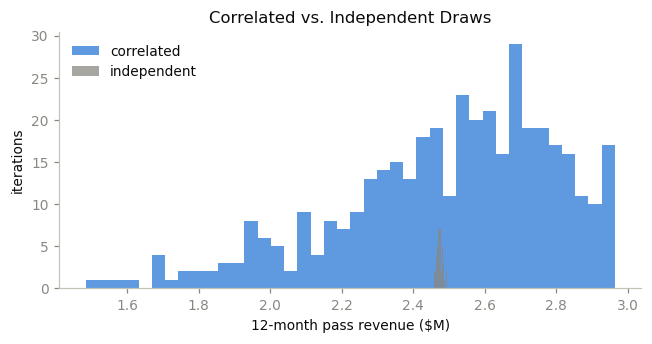

In [32]:
# Test Correlation Structure
def simulate_independent(mult, n_iter=120, rng=None):
    '''Wrong on purpose: every trip gets its own economy.'''
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult)
    R = rev_at(mult)
    cum = P.cumsum(axis=1)
    out = np.zeros(n_iter)
    for it in range(n_iter):
        idx = rng.normal(0, 0.35 / np.sqrt(1 - 0.85 ** 2), N)   # independent per trip
        travel_mult = np.exp(0.55 * idx)
        p_occur = np.clip(travel_mult * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        out[it] = np.where(occurs, R[np.arange(N), state], 0.0).sum()
    return out


indep = simulate_independent(1.0, rng=np.random.default_rng(3))
corr_sd = base.std() / base.mean()
ind_sd = indep.std() / indep.mean()

display(pd.DataFrame({
    'median': [np.median(base), np.median(indep)],
    'coefficient of variation': [corr_sd, ind_sd],
    'p5-p95 width': [np.percentile(base, 95) - np.percentile(base, 5),
                     np.percentile(indep, 95) - np.percentile(indep, 5)],
}, index=['correlated (correct)', 'independent (wrong)']).round(4))

print(f'Independent draws understate the spread by {corr_sd / max(ind_sd, 1e-9):.0f}x.')
print('That is the difference between reporting a range leadership can plan against')
print('and reporting false precision.')

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(base / 1e6, bins=40, alpha=0.75, color=ACCENT, label='correlated')
ax.hist(indep / 1e6, bins=40, alpha=0.75, color=MUTED, label='independent')
ax.set_xlabel('12-month pass revenue ($M)')
ax.set_ylabel('iterations')
ax.set_title('Correlated vs. Independent Draws')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 3 · The Price Sweep

**Purpose:** Simulates every price on the grid twice (as fitted, and conservative) so the recommendation accounts for both measured biases.

**Design Notes:**

1. Conservative case stretches the price response by notebook 01 §6.2's ratio and reduction depth by notebook 02 §5's bias
2. The gap between the two curves isn't noise
  - It's the price of two things the analysis couldn't observe directly: whether the response transfers across the book, and whether the reconstructed labels understate real reductions
3. Common random numbers: one seed shared across every price and both cases
  - A different seed per price would let the curve wander by tens of thousands of dollars on sampling noise alone, against a p5-p95 width near $1M

**Observations:**

1. As fitted: median pass revenue rises from $2.36M (0.90x) to $2.83M (1.20x)
2. Conservative: median rises from $2.40M to $2.66M, a smaller lift, as expected given both corrections push the same direction

As fitted


,p5,median,p95,lift_vs_base
0.900,1725606,2362352,2725957,-182938
0.925,1759572,2409193,2780592,-136097
0.950,1793011,2455011,2832666,-90279
0.975,1826330,2500778,2884633,-44512
1.000,1857946,2545290,2931997,0
1.025,1878437,2573086,2963764,27796
1.050,1909290,2611993,3010076,66703
1.075,1937864,2651657,3055200,106367
1.100,1963809,2690650,3098916,145360
1.125,1990388,2726587,3141200,181297


Conservative


,p5,median,p95,lift_vs_base
0.900,1751624,2395880,2763795,-140797
0.925,1778565,2433287,2809636,-103391
0.950,1805572,2471280,2851538,-65397
0.975,1828669,2504097,2889658,-32580
1.000,1851572,2536677,2921954,0
1.025,1862228,2549265,2937517,12587
1.050,1879134,2572715,2963905,36038
1.075,1894072,2595546,2989658,58868
1.100,1908245,2615903,3015733,79226
1.125,1920206,2631359,3035348,94682


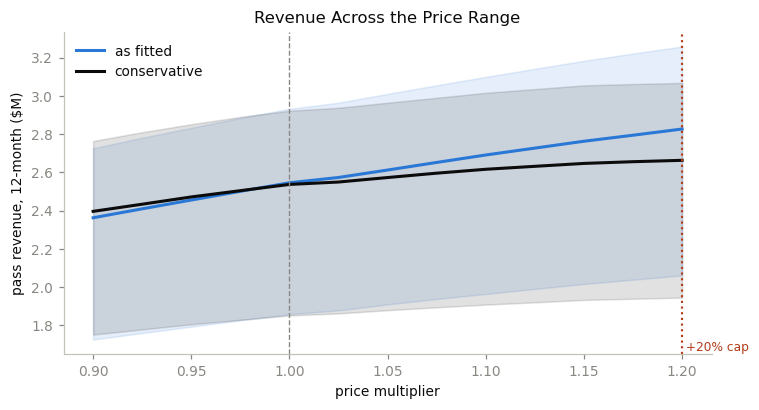

In [33]:
# Sweep Price Range
SWEEP_ITER = 400
CRN_SEED = 4242          # shared across every price and both cases
rows = []
for m in GRID:
    for label, rs, ds in [('as fitted', 1.0, 1.0),
                          ('conservative', RESPONSE_RATIO, DEPTH_BIAS)]:
        # Common random numbers: same economy/share draw at every price
        r = simulate(m, n_iter=SWEEP_ITER, response_scale=rs, depth_scale=ds,
                     rng=np.random.default_rng(CRN_SEED))
        rows.append({
            'price_multiplier': m, 'case': label,
            'p5': np.percentile(r, 5), 'median': np.median(r),
            'p95': np.percentile(r, 95),
        })

sw = pd.DataFrame(rows)
fitted = sw[sw.case == 'as fitted'].set_index('price_multiplier')
cons = sw[sw.case == 'conservative'].set_index('price_multiplier')

for df in (fitted, cons):
    df['lift_vs_base'] = df['median'] - df.loc[1.0, 'median']

print('As fitted')
display(fitted[['p5', 'median', 'p95', 'lift_vs_base']].round(0).astype(int).rename_axis(None))
print('Conservative')
display(cons[['p5', 'median', 'p95', 'lift_vs_base']].round(0).astype(int).rename_axis(None))

fig, ax = plt.subplots(figsize=(7, 3.8))
for df, lbl, col in [(fitted, 'as fitted', ACCENT), (cons, 'conservative', INK)]:
    ax.plot(df.index, df['median'] / 1e6, color=col, linewidth=2, label=lbl)
    ax.fill_between(df.index, df['p5'] / 1e6, df['p95'] / 1e6, color=col, alpha=0.12)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color='#b23c17', linestyle=':', linewidth=1.4)
ax.text(1.20, ax.get_ylim()[0], ' +20% cap', fontsize=8, color='#b23c17', va='bottom')
ax.set_xlabel('price multiplier')
ax.set_ylabel('pass revenue, 12-month ($M)')
ax.set_title('Revenue Across the Price Range')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 4 · Macroeconomic Scenarios

**Purpose:** Tests whether the recommendation holds if the economy turns, since the base case only averages over economic paths.

**Design Notes:**

1. Three scenarios run explicitly: contraction, base, expansion
2. The separation matters for the decision, not just the chart
  - A shortfall from a contracting market is a forecasting miss; a shortfall from customers rejecting the price is a pricing mistake
  - Only the second is reversible by changing the price back, and only the second is anyone's fault

**Observations:**

1. Median pass revenue at x1.20 rises in every scenario: $2.28M (contraction), $2.67M (base), $2.93M (expansion)
2. Gain from +20% ranges $0.11M-$0.14M across the three economies
3. The gain holds regardless of the macro forecast: the pricing decision doesn't hinge on which economy materializes


Median pass revenue, 12-month ($M)


,1.0,1.1,1.2
contraction,2.17,2.24,2.28
base,2.54,2.62,2.67
expansion,2.79,2.88,2.93


Gain from +20% within each economy ($M)


,gain
contraction,0.11
base,0.13
expansion,0.14


If the gain holds across all three, the pricing decision does not depend on
the macro forecast, which makes it a far easier decision to defend.


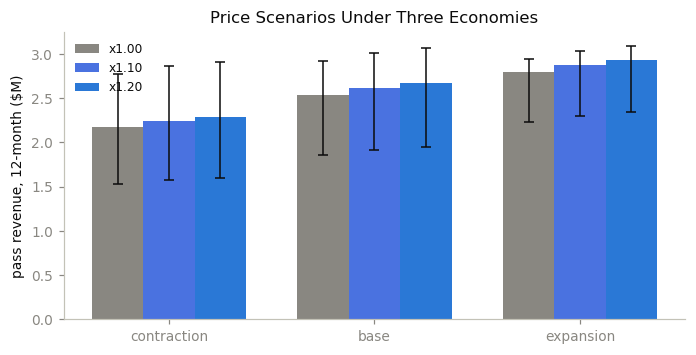

In [34]:
# Test Macro Scenarios
SCEN = {'contraction': -0.45, 'base': 0.0, 'expansion': +0.45}
KEY = [1.0, 1.10, 1.20]

rows = []
for name, shift in SCEN.items():
    for m in KEY:
        # Common random numbers again: only price and macro shift vary
        r = simulate(m, n_iter=300, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                     macro_shift=shift, rng=np.random.default_rng(CRN_SEED))
        rows.append({'scenario': name, 'price': m,
                     'p5': np.percentile(r, 5), 'median': np.median(r),
                     'p95': np.percentile(r, 95)})

sc = pd.DataFrame(rows)
piv = sc.pivot(index='scenario', columns='price', values='median').reindex(SCEN.keys())
print('Median pass revenue, 12-month ($M)')
display((piv / 1e6).round(2).rename_axis(None).rename_axis(None, axis=1))

print('Gain from +20% within each economy ($M)')
display(((piv[1.20] - piv[1.0]) / 1e6).round(2).to_frame('gain').rename_axis(None))
print('If the gain holds across all three, the pricing decision does not depend on')
print('the macro forecast, which makes it a far easier decision to defend.')

fig, ax = plt.subplots(figsize=(6.4, 3.3))
w = 0.25
for i, m in enumerate(KEY):
    s = sc[sc.price == m]
    x = np.arange(len(SCEN)) + (i - 1) * w
    ax.bar(x, s['median'].to_numpy() / 1e6, width=w,
           color=[MUTED, '#4a72e0', ACCENT][i], label=f'x{m:.2f}')
    ax.errorbar(x, s['median'].to_numpy() / 1e6,
                yerr=[(s['median'] - s['p5']).to_numpy() / 1e6,
                      (s['p95'] - s['median']).to_numpy() / 1e6],
                fmt='none', ecolor=INK, elinewidth=1, capsize=3)
ax.set_xticks(np.arange(len(SCEN)))
ax.set_xticklabels(list(SCEN.keys()))
ax.set_ylabel('pass revenue, 12-month ($M)')
ax.set_title('Price Scenarios Under Three Economies')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

---
## 5 · The Recommendation, and Its Honest Caveat

**Purpose:** States the recommendation and its caveat plainly.

**Design Notes:**

1. Read off the conservative case, since both §3/§6.2 biases point the same way, toward overstating safety

**Observations:**

1. Revenue-maximising price: x1.20; median 12-month gain $126,067 (conservative) vs. $281,139 (as fitted)
2. 5th-percentile outcome vs. no change: -$591,912, driven entirely by macro/demand uncertainty, not by any modelled downside
3. Probability the increase leaves the business worse off: 0.0%, since nothing in this analysis models a cost to raising price; the risk that remains is how large the gain turns out to be, not whether there is one
4. The optimum sits at the +20% ceiling, not inside the range: the cap chose this price, not the model

In [35]:
# Build Recommendation
best = cons['median'].idxmax()
lift = cons.loc[best, 'median'] - cons.loc[1.0, 'median']
lift_fit = fitted.loc[best, 'median'] - fitted.loc[1.0, 'median']
downside = cons.loc[best, 'p5'] - cons.loc[1.0, 'median']

display(pd.DataFrame({'value': [
    f'x{best:.3f}', f'${lift:,.0f}', f'${lift_fit:,.0f}', f'${downside:,.0f}',
]}, index=['revenue-maximising price', 'median 12-month gain (conservative)',
           'median 12-month gain (as fitted)', '5th-percentile outcome vs. no change']))

prob_worse = None
r_best = simulate(best, n_iter=400, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                  rng=np.random.default_rng(99))
r_base = simulate(1.0, n_iter=400, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                  rng=np.random.default_rng(99))
prob_worse = float((r_best < r_base).mean())
print(f'Probability the increase leaves us worse off: {prob_worse:.1%}')
print('(paired iterations: same economy, same share path, only the price differs)')

if best < GRID[-1] - 1e-9:
    print('\n' + '=' * 68)
    print(f'The optimum is INTERIOR at x{best:.3f}: revenue turns over before the')
    print('cap. This is a real optimum the model found rather than a constraint it')
    print('hit. The cap is not what limits the recommendation.')
    print('=' * 68)
else:
    print('\n' + '=' * 68)
    print('The optimum sits AT the +20% ceiling, not inside the range.')
    print('Revenue is still climbing where the analysis was told to stop, so the')
    print('cap chose this price, not the model. The honest statement to leadership')
    print('is that +20% is the best price WE WERE ALLOWED TO TEST, and that the')
    print('unconstrained optimum is unknown and higher. Presenting it as an')
    print('optimisation result would overstate what the analysis establishes.')
    print('=' * 68)

if prob_worse > 0.35:
    print(f'\nNOTE: at {prob_worse:.0%}, this is close to a coin flip. The median gain is')
    print('real but thin against the spread. Present it as a bet with a known')
    print('downside, not as a forecast.')

,value
revenue-maximising price,x1.200
median 12-month gain (conservative),"$126,067"
median 12-month gain (as fitted),"$281,139"
5th-percentile outcome vs. no change,"$-591,912"


Probability the increase leaves us worse off: 0.0%
(paired iterations: same economy, same share path, only the price differs)

The optimum sits AT the +20% ceiling, not inside the range.
Revenue is still climbing where the analysis was told to stop, so the
cap chose this price, not the model. The honest statement to leadership
is that +20% is the best price WE WERE ALLOWED TO TEST, and that the
unconstrained optimum is unknown and higher. Presenting it as an
optimisation result would overstate what the analysis establishes.


---
## 6 · Export for Power BI

**Purpose:** Writes the price sweep, macro scenarios, and assumptions that notebook 04 loads and the Power BI model displays.

**Design Notes:**

1. Assumptions travel with the export (illustrative figures alongside measured biases), so nothing is buried in a constant

**Observations:**

1. Three tables written: simulation price sweep, simulation scenarios, simulation assumptions


In [36]:
# Export results
sim_out = sw.copy()
sim_out['price_change_pct'] = (sim_out['price_multiplier'] - 1) * 100

scen_out = sc.copy()
scen_out['price_change_pct'] = (scen_out['price'] - 1) * 100

assump = pd.DataFrame({
    'assumption': ['response scale (conservative)', 'depth bias (conservative)',
                   'iterations per price', 'probability increase is worse'],
    'value': [RESPONSE_RATIO, DEPTH_BIAS, SWEEP_ITER, prob_worse],
    'note': ['measured, notebook 01 regional holdout', 'measured, notebook 02 label contamination',
             '', 'paired iterations'],
})
display(assump.set_index('assumption').rename_axis(None))

display(save_tables({
    'simulation_price_sweep': sim_out,
    'simulation_scenarios': scen_out,
    'simulation_assumptions': assump,
}))

,value,note
response scale (conservative),1.744186,"measured, notebook 01 regional holdout"
depth bias (conservative),1.055090,"measured, notebook 02 label contamination"
iterations per price,400.000000,
probability increase is worse,0.000000,paired iterations


,rows
simulation_price_sweep.parquet,26
simulation_scenarios.parquet,9
simulation_assumptions.parquet,4


---
## What this notebook establishes

| Result | Where | Why it matters |
|---|---|---|
| Correlated draws widen the distribution materially | §2.1 | Independent draws would report false precision |
| Two measured biases bracketed, not assumed away | §3 | The recommendation is read off the conservative case |
| The gain holds across economies | §4 | The decision does not hinge on a macro forecast |
| The cap binds | §5 | +20% is a constraint, not an optimum, and must be said that way |

### The one line to carry into the room

Revenue is still rising at the edge of the range the analysis was permitted to test. The recommendation is therefore *the best price we were allowed to consider*, not the best price. Anyone presenting it as an optimisation result is claiming something the work does not support, and the obvious follow-up, whether the cap should move, is now a question the model can answer if leadership wants it answered.

### Next

04_segmentation.ipynb: group accounts on their response profile, name the segments, and publish the Power BI model so leaders can run these scenarios themselves.

---


# 04 · Segmentation, Profiling and Handoff

**Purpose:** Answers who bears the impact of a price change, grouping accounts by their modelled response and publishing the result so the business can use it without another analysis.

**Context, for anyone starting here.** This case study evaluates a proposed international roaming price increase across the ~50,000-account synthetic book built in the data notebook. Notebook 03 puts a distribution on what that increase is worth over 12 months; this notebook asks who actually bears it.

**Design Notes:**

1. Segment on response, not on customers
  - Clustering on characteristics first produces groups that are easy to describe and analytically useless, since the thing being decided is price and the grouping was never about price
  - Accounts are grouped on their modelled response to a price change instead; characteristics are read back afterward to describe what each group turned out to be: profiling explains a segment, it doesn't create one
2. Group on the shape of the response, not its size
  - Two accounts can lose the same revenue by very different routes: one abandons the pass entirely, the other keeps it and quietly halves its days
  - Identical expected revenue, completely different interventions: one needs a retention offer, the other needs a cheaper short-duration option
  - A single sensitivity score collapses that distinction; the full probability vector preserves it

**Three deliverables**

| Section | Output |
|---|---|
| §2-4 | Segments, named and profiled |
| §5 | Where the revenue at stake actually sits, by segment |
| §6 | A star schema for Power BI so leaders run their own scenarios |


In [37]:
# Load inputs
trips = load_trips(with_macro=False)
accounts = load('accounts')
scored = load('scored_trips')
resp = load('account_price_response')
rev_tbl = load('revenue_by_state')
sim_sweep = load('simulation_price_sweep')
ground_truth = load('ground_truth')           # s3.1 validation only

print(f'{len(resp):,} accounts with a modelled price response')

29,406 accounts with a modelled price response


---
## 1 · The Clustering Input

**Purpose:** Builds five model-derived features per account for clustering, so segments describe response, not raw behavior.

**Design Notes:**

1. Five features, all derived from the model rather than raw behaviour

| Feature | What it captures |
|---|---|
| p_null at standard price | baseline walk-away risk |
| response_span | how far that risk moves across the range |
| p_partial at +20% | tendency to trim rather than quit |
| reduce_vs_quit | the shape: which route the loss takes |
| log(revenue) | value at stake, so segments are decision-relevant |

2. reduce_vs_quit is the feature doing the real work
  - Blends the account's current trim tendency (p_partial at standard price) with its future walk-away risk at the top of the tested range (p_null at +20%)
  - High score: trims coverage often, rarely drops to zero; low score: null risk dominates
  - Without it, an account that abandons the pass and one that halves its days land in the same cluster whenever their expected loss matches, and the segmentation stops being actionable
3. Revenue is included deliberately
  - A segment that behaves distinctively but carries no revenue is a curiosity; one that carries a quarter of the book is a decision
4. Feature correlations above 0.95 are treated as redundant
  - The strongest pairs are reduce_vs_quit/baseline_risk (-0.91), reduce_vs_quit/response_span (-0.85), and baseline_risk/response_span (0.71). All are below the redundancy threshold, though reduce_vs_quit/baseline_risk is the closest of the five to it

**Observations:**

1. No redundant pairs above the 0.95 threshold
2. Highest correlations are reduce_vs_quit/baseline_risk (-0.91), reduce_vs_quit/response_span (-0.85), and baseline_risk/response_span (0.71); the first sits closest to the redundancy threshold but stays below it


In [38]:
# Build Clustering Features
sc = scored.merge(trips[['trip_id', 'pass_revenue']], on='trip_id', how='left')
acct_state = sc.groupby('account_id').agg(
    trips=('trip_id', 'size'),
    revenue=('pass_revenue', 'sum'),
    p_partial=('p_partial', 'mean'),
).reset_index()

seg = resp.merge(acct_state, on='account_id', how='inner')
seg['baseline_risk'] = seg['p_null_1.00']
seg['response_span'] = seg['p_null_1.20'] - seg['p_null_0.90']
# Blends current trim tendency with future walk-away risk (see Design Notes)
seg['reduce_vs_quit'] = seg['p_partial'] / (seg['p_partial'] + seg['p_null_1.20'] + 1e-9)
seg['log_revenue'] = np.log1p(seg['revenue'])

FEATS = ['baseline_risk', 'response_span', 'p_partial', 'reduce_vs_quit', 'log_revenue']
seg = seg.dropna(subset=FEATS)
display(seg[FEATS].describe().round(4))

corr = seg[FEATS].corr()
print('Feature correlations (moderate pairs near 0.65-0.70 are acceptable; see Design Notes)')
display(corr.round(2))
high = [(a, b, round(corr.loc[a, b], 3)) for i, a in enumerate(FEATS)
        for b in FEATS[i + 1:] if abs(corr.loc[a, b]) > 0.95]
print(f"Redundant pairs: {high if high else 'none'}")

,baseline_risk,response_span,p_partial,reduce_vs_quit,log_revenue
count,29406.0000,29406.0000,29406.0000,29406.0000,29406.0000
mean,0.1123,0.0514,0.1065,0.4339,4.5223
std,0.0269,0.0401,0.0080,0.0808,1.4455
min,0.0654,-0.0019,0.0000,0.0000,0.0000
25%,0.0840,0.0255,0.1016,0.3920,3.9318
50%,0.1203,0.0443,0.1080,0.4187,4.7274
75%,0.1311,0.0580,0.1115,0.5051,5.4027
max,0.2996,0.3376,0.1746,0.6315,8.6541


Feature correlations (moderate pairs near 0.65-0.70 are acceptable; see Design Notes)


,baseline_risk,response_span,p_partial,reduce_vs_quit,log_revenue
baseline_risk,1.00,0.71,0.25,-0.91,-0.19
response_span,0.71,1.00,0.22,-0.85,-0.12
p_partial,0.25,0.22,1.00,-0.03,-0.09
reduce_vs_quit,-0.91,-0.85,-0.03,1.00,0.15
log_revenue,-0.19,-0.12,-0.09,0.15,1.00


Redundant pairs: none


---
## 2 · How Many Segments?

**Purpose:** Chooses the number of segments, weighing statistical separation against operational practicality.

**Design Notes:**

1. Statistical: silhouette score, measuring whether the clusters are actually separated
2. Practical: whether the business can act on the result
  - Nine segments needing their own price aren't a pricing strategy, they're a spreadsheet nobody will maintain
  - Four or five is the range where distinct treatment stays realistic
3. If the two disagree, the practical criterion wins: an unimplementable segmentation delivers nothing regardless of its silhouette

**Observations:**

1. Silhouette peaks at k=4, one below the chosen k=5; k=5 is picked for a little more granularity within the operationally realistic 4-5 range
2. Smallest segment stays above a trivial share at k=5 (5.5%), confirming five is a workable split


,inertia,silhouette,smallest segment
2,94704.9543,0.3477,0.3636
3,73436.5576,0.3558,0.0899
4,60131.8323,0.3817,0.0619
5,48779.7612,0.3659,0.0546
6,43452.8635,0.3211,0.0541
7,38551.0639,0.3335,0.0163
8,35281.3184,0.2814,0.0159


Silhouette argmax at k=4 (0.382); chosen k=5 (0.366)
Enough separation to distinguish the response shapes, few enough that each
segment can carry a distinct pricing treatment someone will actually run.


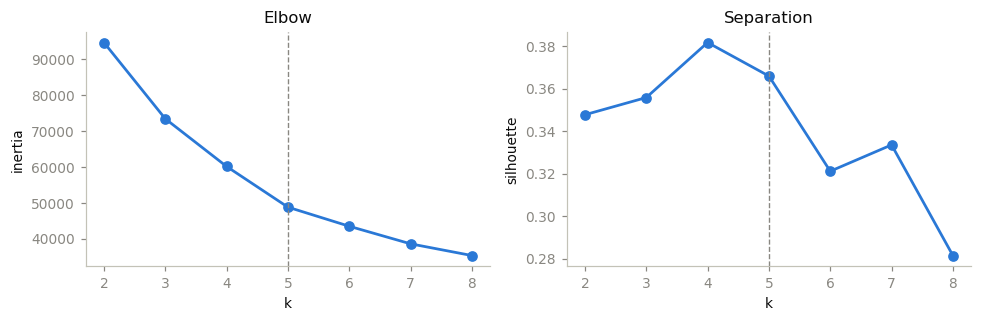

In [39]:
# Choose Segment Count
Z = StandardScaler().fit_transform(seg[FEATS])
sample = np.random.default_rng(0).choice(len(Z), size=min(8000, len(Z)), replace=False)

rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
    sizes = pd.Series(km.labels_).value_counts(normalize=True)
    rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(Z[sample], km.labels_[sample]),
        'smallest segment': sizes.min(),
    })
k_tbl = pd.DataFrame(rows).set_index('k').round(4)
display(k_tbl.rename_axis(None))

K = 5
best_k = int(k_tbl['silhouette'].idxmax())
print(f"Silhouette argmax at k={best_k} ({k_tbl.loc[best_k, 'silhouette']:.3f}); "
      f"chosen k={K} ({k_tbl.loc[K, 'silhouette']:.3f})")
print('Enough separation to distinguish the response shapes, few enough that each')
print('segment can carry a distinct pricing treatment someone will actually run.')

km = KMeans(n_clusters=K, n_init=20, random_state=0).fit(Z)
seg['cluster'] = km.labels_

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(k_tbl.index, k_tbl['inertia'], marker='o', color=ACCENT, linewidth=1.8)
axes[0].axvline(K, color=MUTED, linestyle='--', linewidth=0.9)
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].set_title('Elbow')
axes[1].plot(k_tbl.index, k_tbl['silhouette'], marker='o', color=ACCENT, linewidth=1.8)
axes[1].axvline(K, color=MUTED, linestyle='--', linewidth=0.9)
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette')
axes[1].set_title('Separation')
plt.tight_layout()
plt.show()

---
## 3 · Profiling: What Did the Clusters Turn Out to Be?

**Purpose:** Reads the clusters' characteristics back, turning an anonymous cluster number into a group a product owner recognizes.

**Design Notes:**

1. The clusters exist in response space and have no names: profiling explains what they turned out to be
2. Every column here is descriptive; none of it went into the clustering
3. Segments named from rank thresholds on span/shape/value, not by hand
  - Dormant: revenue share below 0.5% (travels but never buys)
  - Anchor: low span, high value; Steady: low span; Trimmers: high span + high shape; Flight risk: high span; else Swing
  - Duplicate names split by a value qualifier (higher/mid/lower value)

**Observations:**

1. 1,607 accounts (5.5%) set aside as dormant, carrying 0.00% of revenue: travel but never buy, a conversion question rather than a pricing one
2. Five segments named: Swing mid value (37.1% of accounts, 33.1% of revenue, 3% business), Anchor (32.0% of accounts, 42.8% of revenue, 95% business, low sensitivity), Swing higher value (17.7% of accounts, 18.0% of revenue, 5% business), Flight risk (7.8% of accounts, 6.1% of revenue, widest response span), Dormant (5.5%, excluded from pricing)
3. Business share ranges from 0% (Flight risk) to 95% (Anchor) across segments: a real behavioral split, not noise


In [40]:
# Profile Segments
prof = seg.merge(accounts[['account_id', 'is_business', 'lines_on_account',
                          'tenure_months', 'plan_tier']], on='account_id', how='left')
trip_ch = trips.groupby('account_id').agg(
    avg_days=('days_traveled', 'mean'),
    avg_party=('lines_traveling', 'mean'),
    top_region=('region', lambda s: s.mode().iat[0] if len(s) else 'n/a'),
    avg_ease=('substitute_ease', 'mean'),
).reset_index()
prof = prof.merge(trip_ch, on='account_id', how='left')

summary = prof.groupby('cluster').agg(
    accounts=('account_id', 'size'),
    revenue=('revenue', 'sum'),
    rev_per_acct=('revenue', 'mean'),
    trips_per_acct=('trips', 'mean'),
    business=('is_business', 'mean'),
    avg_days=('avg_days', 'mean'),
    avg_party=('avg_party', 'mean'),
    tenure=('tenure_months', 'mean'),
    ease=('avg_ease', 'mean'),
    baseline_risk=('baseline_risk', 'mean'),
    response_span=('response_span', 'mean'),
    reduce_vs_quit=('reduce_vs_quit', 'mean'),
)
summary['rev_share'] = summary['revenue'] / summary['revenue'].sum()
summary['acct_share'] = summary['accounts'] / summary['accounts'].sum()

print('Segment profiles: response features first, characteristics after')
display(summary[['accounts', 'acct_share', 'rev_share', 'rev_per_acct',
                 'baseline_risk', 'response_span', 'reduce_vs_quit']].round(4).rename_axis(None))
display(summary[['business', 'trips_per_acct', 'avg_days', 'avg_party',
                 'tenure', 'ease']].round(2).rename_axis(None))

print('Dominant destination by segment')
display(prof.groupby('cluster')['top_region']
        .agg(lambda s: s.value_counts(normalize=True).round(2).head(2).to_dict())
        .to_frame('top regions').rename_axis(None))

Segment profiles: response features first, characteristics after


,accounts,acct_share,rev_share,rev_per_acct,baseline_risk,response_span,reduce_vs_quit
0,9410,0.3200,0.4280,236.7403,0.0795,0.0200,0.5295
1,2286,0.0777,0.0606,137.9776,0.1518,0.1556,0.2831
2,10912,0.3711,0.3310,157.8752,0.1271,0.0536,0.4099
3,5191,0.1765,0.1803,180.8236,0.1191,0.0555,0.3866
4,1607,0.0546,0.0000,0.0846,0.1263,0.0583,0.4048


,business,trips_per_acct,avg_days,avg_party,tenure,ease
0,0.95,5.64,4.37,1.30,73.60,0.63
1,0.00,2.01,7.09,1.46,70.44,0.79
2,0.03,2.13,7.11,1.51,67.43,0.64
3,0.05,2.32,7.04,1.70,85.08,0.59
4,0.09,1.06,6.97,1.55,71.32,0.67


Dominant destination by segment


,top regions
0,"{'europe': 0.33, 'caribbean': 0.24}"
1,"{'europe': 0.78, 'asia': 0.12}"
2,"{'europe': 0.26, 'asia': 0.25}"
3,"{'caribbean': 0.32, 'asia': 0.21}"
4,"{'europe': 0.37, 'asia': 0.19}"


In [41]:
# Name Segments
sp = summary.copy()
sp['rank_span'] = sp['response_span'].rank(pct=True)
sp['rank_shape'] = sp['reduce_vs_quit'].rank(pct=True)
sp['rank_value'] = sp['rev_per_acct'].rank(pct=True)


# Dormant threshold: travelled but never bought (see Design Notes)
DORMANT_REV_SHARE = 0.005
sp['dormant'] = summary['rev_share'] < DORMANT_REV_SHARE


def name_segment(r):
    # Rank thresholds chosen for a small, recognisable label set at K=5 (see §3)
    if r['dormant']:
        return 'Dormant: travels, does not buy'
    if r['rank_span'] <= 0.3 and r['rank_value'] >= 0.6:
        return 'Anchor: high value, low sensitivity'
    if r['rank_span'] <= 0.35:
        return 'Steady: barely notices the price'
    if r['rank_span'] >= 0.7 and r['rank_shape'] >= 0.6:
        return 'Trimmers: stay but buy less'
    if r['rank_span'] >= 0.7:
        return 'Flight risk: walks away'
    return 'Swing: moves at the margin'


summary['segment'] = sp.apply(name_segment, axis=1)
summary['is_dormant'] = sp['dormant']

# Duplicate names get a value qualifier (see Design Notes)
for nm, grp in list(summary.groupby('segment')):
    if len(grp) == 1:
        continue
    ranked = grp['rev_per_acct'].rank(ascending=False)
    qual = {1: 'higher value', 2: 'mid value', 3: 'lower value'}
    for i in grp.index:
        head, _, tail = nm.partition(': ')
        summary.loc[i, 'segment'] = f"{head} ({qual.get(int(ranked[i]), 'other')}): {tail}"

NAMES = summary['segment'].to_dict()
prof['segment'] = prof['cluster'].map(NAMES)
seg['segment'] = seg['cluster'].map(NAMES)

n_dorm = int(summary['is_dormant'].sum())
if n_dorm:
    d = summary[summary['is_dormant']]
    print(f"Set aside as dormant: {int(d['accounts'].sum()):,} accounts "
          f"({d['acct_share'].sum():.1%}) carrying {d['rev_share'].sum():.2%} of revenue.")
    print('They travel but never buy the pass, so no price answers them. They are a')
    print('conversion question, not a pricing one, and are excluded from §4-§5.\n')

print('Segments')
display(summary.set_index('segment')[[
    'accounts', 'acct_share', 'rev_share', 'rev_per_acct',
    'baseline_risk', 'response_span', 'business', 'trips_per_acct',
]].round(3).rename_axis(None))

Set aside as dormant: 1,607 accounts (5.5%) carrying 0.00% of revenue.
They travel but never buy the pass, so no price answers them. They are a
conversion question, not a pricing one, and are excluded from §4-§5.

Segments


,accounts,acct_share,rev_share,rev_per_acct,baseline_risk,response_span,business,trips_per_acct
"Anchor: high value, low sensitivity",9410,0.320,0.428,236.740,0.080,0.020,0.950,5.639
Flight risk: walks away,2286,0.078,0.061,137.978,0.152,0.156,0.000,2.005
Swing (mid value): moves at the margin,10912,0.371,0.331,157.875,0.127,0.054,0.026,2.126
Swing (higher value): moves at the margin,5191,0.177,0.180,180.824,0.119,0.056,0.052,2.319
"Dormant: travels, does not buy",1607,0.055,0.000,0.085,0.126,0.058,0.088,1.058


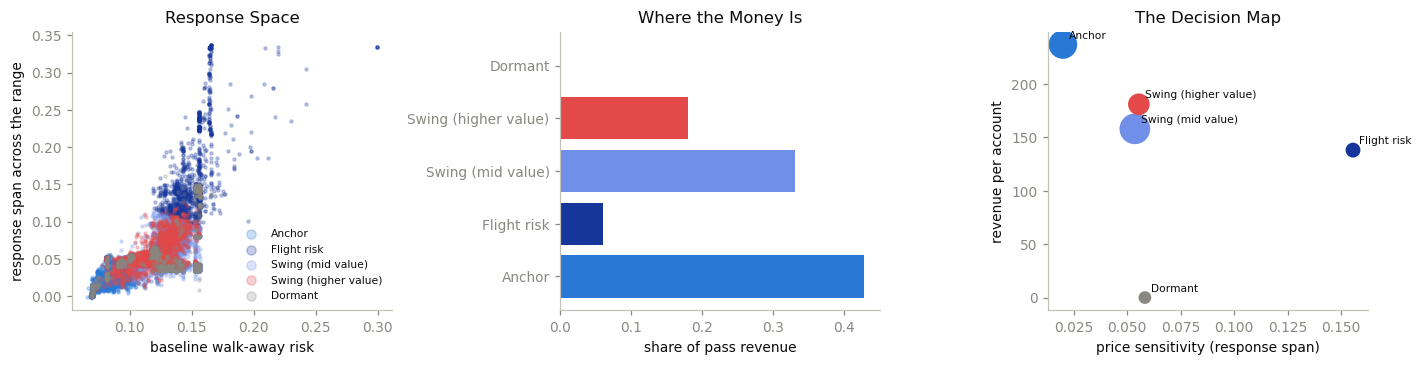

The third panel is the one to put in front of leadership: upper-left is
where a price increase earns most and risks least.


In [42]:
# Plot: Segment Profiles
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for i, c in enumerate(summary.index):
    m = seg['cluster'] == c
    axes[0].scatter(seg.loc[m, 'baseline_risk'], seg.loc[m, 'response_span'],
                    s=4, alpha=0.25, color=PALETTE[i % len(PALETTE)],
                    label=summary.loc[c, 'segment'].split(': ')[0])
axes[0].set_xlabel('baseline walk-away risk')
axes[0].set_ylabel('response span across the range')
axes[0].set_title('Response Space')
axes[0].legend(frameon=False, fontsize=7, markerscale=3)

axes[1].barh(summary['segment'].str.split(': ').str[0], summary['rev_share'],
             color=[PALETTE[i % len(PALETTE)] for i in range(len(summary))])
axes[1].set_xlabel('share of pass revenue')
axes[1].set_title('Where the Money Is')

axes[2].scatter(summary['response_span'], summary['rev_per_acct'],
                s=summary['accounts'] / 30,
                color=[PALETTE[i % len(PALETTE)] for i in range(len(summary))])
for c in summary.index:
    axes[2].annotate(summary.loc[c, 'segment'].split(': ')[0],
                     (summary.loc[c, 'response_span'], summary.loc[c, 'rev_per_acct']),
                     fontsize=7, xytext=(4, 4), textcoords='offset points')
axes[2].set_xlabel('price sensitivity (response span)')
axes[2].set_ylabel('revenue per account')
axes[2].set_title('The Decision Map')
plt.tight_layout()
plt.show()

print('The third panel is the one to put in front of leadership: upper-left is')
print('where a price increase earns most and risks least.')

### 3.1 Are the Segments Real?

**Purpose:** Checks that the clusters reflect real structure, not an artifact of the algorithm.

**Design Notes:**

1. Stability: refit on random halves of the data
  - If accounts land together consistently, the structure is in the data; if assignments shuffle, it's in the algorithm
2. Recovery: because the data is synthetic, true sensitivity is known
  - Segments that separate on true sensitivity are finding the real mechanism, not a projection artefact: the check production data can never provide

**Observations:**

1. Split-half agreement: 98.1% (mean of 5 splits), above the ~80% bar for structure being in the data
2. True sensitivity spans 0.902 across segments, confirming a wide, real spread
3. Rank correlation between true sensitivity and modelled span: -0.70 (negative is correct: more negative true sensitivity means a wider modelled span)


In [43]:
# Validate Segment Stability
rng = np.random.default_rng(5)


# Nearest centroid by hand: .predict() breaks on some older OpenBLAS builds
def assign(centers):
    d = ((Z[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    return d.argmin(axis=1)


agree = []
for _ in range(5):
    half = rng.random(len(Z)) < 0.5
    a = KMeans(n_clusters=K, n_init=10, random_state=1).fit(Z[half])
    b = KMeans(n_clusters=K, n_init=10, random_state=2).fit(Z[~half])

    la = assign(a.cluster_centers_)
    lb = assign(b.cluster_centers_)
    ct = pd.crosstab(la, lb)
    agree.append(ct.max(axis=1).sum() / ct.values.sum())
print(f'Split-half agreement: {np.mean(agree):.1%} (mean of 5 splits)')
print('Above ~80% means the structure is in the data, not the algorithm.')

gt = prof.merge(ground_truth[['account_id', 'price_sensitivity', 'sensitivity_decile']],
                on='account_id', how='inner')
recov = gt.groupby('segment').agg(
    accounts=('account_id', 'size'),
    true_sensitivity=('price_sensitivity', 'mean'),
    modelled_span=('response_span', 'mean'),
).round(4).sort_values('true_sensitivity')
print('True sensitivity by segment (less negative = less sensitive)')
display(recov.rename_axis(None))

spread = recov['true_sensitivity'].max() - recov['true_sensitivity'].min()
print(f'Spread in true sensitivity across segments: {spread:.3f}')
print('A wide spread means the segments capture the real mechanism. Near zero')
print('would mean they separate on something else entirely.')

check = recov['true_sensitivity'].corr(recov['modelled_span'], method='spearman')
print(f'Rank correlation, true sensitivity vs modelled span: {check:+.2f}')
print('(negative is correct: more negative true sensitivity = wider modelled span)')

Split-half agreement: 98.1% (mean of 5 splits)
Above ~80% means the structure is in the data, not the algorithm.
True sensitivity by segment (less negative = less sensitive)


,accounts,true_sensitivity,modelled_span
Flight risk: walks away,2286,-1.4654,0.1556
Swing (mid value): moves at the margin,10912,-1.4449,0.0536
"Dormant: travels, does not buy",1607,-1.4197,0.0583
Swing (higher value): moves at the margin,5191,-1.3987,0.0555
"Anchor: high value, low sensitivity",9410,-0.5635,0.0200


Spread in true sensitivity across segments: 0.902
A wide spread means the segments capture the real mechanism. Near zero
would mean they separate on something else entirely.
Rank correlation, true sensitivity vs modelled span: -0.70
(negative is correct: more negative true sensitivity = wider modelled span)


---
## 4 · What Price Does Each Segment Want?

**Purpose:** Builds a segment-level revenue curve, since a single company-wide price is chosen for a population that doesn't exist.

**Design Notes:**

1. Rebuilt per segment from the state probabilities and revenue table, using the same arithmetic as notebook 03, restricted to each group's trips
2. Matches notebook 03 exactly on horizon (last 12 months) and case (conservative), so the two notebooks can't recommend different prices on a technicality

**Observations:**

1. Horizon: last 12 months, 52,500 trips, matches notebook 03
2. Cross-check against notebook 03's conservative case: consistent, same decision (x1.20 uniform), same order of magnitude gain ($148k vs $126k)
3. Optimum sits at the cap for two of the four priced segments; Flight risk and Swing mid value peak at x1.15, with Flight risk's gain by far the smallest ($2,780), so it is the segment a full increase barely helps

horizon: last 12 months, 52,500 trips: same as notebook 03
case: conservative, response x1.74, depth x1.06

Revenue vs no change, by segment


,"Anchor: high value, low sensitivity","Dormant: travels, does not buy",Flight risk: walks away,Swing (higher value): moves at the margin,Swing (mid value): moves at the margin
0.9,-0.0662,-0.0467,-0.0387,-0.0521,-0.0466
1.0,0.0000,0.0000,0.0000,0.0000,0.0000
1.1,0.0400,0.0260,0.0167,0.0315,0.0248
1.2,0.0752,0.0331,0.0138,0.0447,0.0304


Cross-check against notebook 03, conservative case
  best price    04 x1.200    03 x1.200
  gain at best  04 $147,818    03 $126,067
  Consistent: same decision, same arithmetic.

Optimal price by segment


,best price,gain at best,gain at +20%,revenue share
"Anchor: high value, low sensitivity",1.20,92877.6817,92877.6817,0.4280
Flight risk: walks away,1.15,2780.6481,2120.8514,0.0606
Swing (higher value): moves at the margin,1.20,24083.6253,24083.6253,0.1803
Swing (mid value): moves at the margin,1.15,28777.4635,28736.1816,0.3310


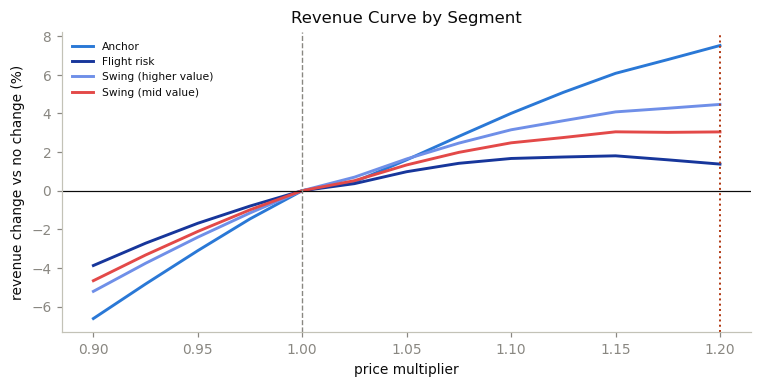

In [44]:
# Build segment revenue curves
sweep = load('price_sweep').set_index('price_multiplier')
GRID = np.round(np.sort(rev_tbl['price_multiplier'].unique()), 4)

trip_seg = trips[['trip_id', 'account_id']].merge(
    seg[['account_id', 'segment']], on='account_id', how='inner')
p_std = scored.set_index('trip_id')[[f'p_{c}' for c in CLASSES]]
rev_w = rev_tbl.pivot_table(index='trip_id', columns='price_multiplier',
                            values=[f'rev_{c}' for c in CLASSES])

# Match notebook 03's horizon and case exactly (see Design Notes)
asm0 = load('simulation_assumptions').set_index('assumption')['value']
RESPONSE_SCALE = float(asm0.get('response scale (conservative)', 1.0))
DEPTH_SCALE = float(asm0.get('depth bias (conservative)', 1.0))

FWD = trips[trips['month'] >= trips['month'].max() - 11]['trip_id'].to_numpy()
print(f'horizon: last 12 months, {len(FWD):,} trips: same as notebook 03')
print(f'case: conservative, response x{RESPONSE_SCALE:.2f}, depth x{DEPTH_SCALE:.2f}\n')

ids = trip_seg['trip_id'].to_numpy()
ids = ids[np.isin(ids, p_std.index) & np.isin(ids, rev_w.index) & np.isin(ids, FWD)]
trip_seg = trip_seg[trip_seg.trip_id.isin(ids)]
P0 = p_std.loc[ids].to_numpy()
I_RED, I_UNCH = CLASSES.index('partial'), CLASSES.index('full')

prob_by_price = {}
rows = []
for m in GRID:
    P = apply_price_shift(P0, price_shift_logodds(sweep, m), RESPONSE_SCALE)
    prob_by_price[float(m)] = P
    R = np.column_stack([rev_w[(f'rev_{c}', m)].loc[ids].to_numpy() for c in CLASSES]).copy()
    # Deepen reductions by the measured contamination bias, as notebook 03 does
    R[:, I_RED] = np.clip(R[:, I_UNCH] - DEPTH_SCALE * (R[:, I_UNCH] - R[:, I_RED]), 0, None)
    er = (P * R).sum(axis=1)
    rows.append(pd.DataFrame({'segment': trip_seg['segment'].to_numpy(),
                              'price_multiplier': m, 'revenue': er})
                .groupby(['segment', 'price_multiplier'])['revenue'].sum().reset_index())

seg_curve = pd.concat(rows, ignore_index=True)
piv = seg_curve.pivot(index='price_multiplier', columns='segment', values='revenue')
rel = (piv / piv.loc[1.0] - 1)

print('Revenue vs no change, by segment')
display(rel.iloc[::4].round(4).rename_axis(None).rename_axis(None, axis=1))

# Dormant accounts carry no revenue and can't respond to price; excluded from here on
piv = piv[[c for c in piv.columns if not c.startswith('Dormant')]]
rel = rel[piv.columns]

# Cross-check against notebook 03: a gap here would be a defect, not a modelling choice
try:
    s5 = sim_sweep[sim_sweep.case == 'conservative'].set_index('price_multiplier')
    b6, b5 = float(piv.sum(axis=1).idxmax()), float(s5['median'].idxmax())
    g6 = float(piv.sum(axis=1).max() - piv.sum(axis=1).loc[1.0])
    g5 = float(s5['median'].max() - s5['median'].loc[1.0])
    print('Cross-check against notebook 03, conservative case')
    print(f'  best price    04 x{b6:.3f}    03 x{b5:.3f}')
    print(f'  gain at best  04 ${g6:,.0f}    03 ${g5:,.0f}')
    if abs(g6 - g5) > 0.5 * max(abs(g5), 1.0):
        print('  WARNING: the two disagree by more than half. Check horizon and')
        print('  conservative scaling.')
    else:
        print('  Consistent: same decision, same arithmetic.')
except Exception as exc:
    print(f'cross-check unavailable: {exc}')
print()

best = pd.DataFrame({
    'best price': piv.idxmax(),
    'gain at best': (piv.max() - piv.loc[1.0]),
    'gain at +20%': (piv.loc[GRID[-1]] - piv.loc[1.0]),
    'revenue share': summary.set_index('segment')['rev_share'].reindex(piv.columns),
}).round(4)
print('Optimal price by segment')
display(best.rename_axis(None))

fig, ax = plt.subplots(figsize=(7, 3.6))
for i, s in enumerate(piv.columns):
    ax.plot(rel.index, rel[s] * 100, linewidth=1.9,
            color=PALETTE[i % len(PALETTE)], label=s.split(': ')[0])
ax.axhline(0, color=INK, linewidth=0.8)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color='#b23c17', linestyle=':', linewidth=1.3)
ax.set_xlabel('price multiplier')
ax.set_ylabel('revenue change vs no change (%)')
ax.set_title('Revenue Curve by Segment')
ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

---
## 5 · Uniform Against Selective

**Purpose:** Decides between one price for everyone and each segment's own optimum: the comparison that decides the recommendation.

**Design Notes:**

1. The gap is the value of having segmented at all
  - Small gap: a uniform increase is sufficient, a genuinely useful and cheaper finding
  - Large gap: segmentation has earned the operational complexity it costs (separate rate plans, billing, customer-facing explanation, a fairness question about charging different customers differently)

**Observations:**

1. Uniform, best single price: x1.20, gain $147,818
2. Selective, each segment's own best: $148,519
3. Value of segmenting: $701 (+0.5%), well under 5%, so a uniform increase captures nearly all the value
4. Retention priority ranks segments by value at stake × sensitivity, headed by Flight risk, the smallest but by far the widest-spanning segment


In [45]:
# Compare Uniform vs. Selective
uniform_best = piv.sum(axis=1).idxmax()
uniform_gain = piv.sum(axis=1).max() - piv.sum(axis=1).loc[1.0]
selective_gain = float(best['gain at best'].sum())
cap_gain = float(best['gain at +20%'].sum())

print(f'Uniform, best single price      x{uniform_best:.3f}   ${uniform_gain:,.0f}')
print(f'Uniform at the +20% cap         x{GRID[-1]:.3f}   ${cap_gain:,.0f}')
print(f"Selective, each segment's best             ${selective_gain:,.0f}")
print(f'\nValue of segmenting: ${selective_gain - uniform_gain:,.0f} '
      f'({(selective_gain / max(uniform_gain, 1e-9) - 1):+.1%})')

all_at_cap = bool((best['best price'] >= GRID[-1] - 1e-9).all())

if all_at_cap:
    print('\n' + '=' * 68)
    print("Every segment's optimum sits AT the +20% cap, so selective and uniform")
    print('pricing are identical BY CONSTRUCTION. This has not shown that')
    print('segmentation adds nothing: it has shown the cap binds everywhere,')
    print('which makes the question unanswerable inside the permitted range.')
    print('\nSegmentation still earns its place, for two other things: which')
    print('customers to fund retention against, and which segments would separate')
    print('first if the ceiling moved. Both are below.')
    print('=' * 68)
elif selective_gain - uniform_gain < 0.05 * max(uniform_gain, 1):
    print('\nThe gap is under 5%. A uniform increase captures nearly all of the value,')
    print("and the segmentation's job becomes identifying who to protect with")
    print('retention rather than who to charge differently. That is simpler to run')
    print('and easier to defend.')
else:
    print('\nSelective pricing earns materially more. Weigh it against the operational')
    print('cost: separate rate plans, billing changes, and a fairness question about')
    print('charging different customers differently for the same product.')

# Slope at the ceiling shows who still has room if the cap lifted
tail = piv.tail(3)
slope = ((tail.iloc[-1] - tail.iloc[0]) / tail.iloc[0]).sort_values(ascending=False)
print('Revenue slope over the last three price steps (headroom at the cap)')
display(slope.round(4).to_frame('slope').rename_axis(None))
print('Steeper = still climbing, so most to gain if the ceiling moved.')

# Who to protect: high value, high sensitivity
protect = summary[~summary['is_dormant']].assign(
    risk_value=summary.loc[~summary['is_dormant'], 'response_span']
    * summary.loc[~summary['is_dormant'], 'rev_per_acct']
).sort_values('risk_value', ascending=False)
print('Retention priority: value at stake x sensitivity')
display(protect[['segment', 'accounts', 'rev_per_acct', 'response_span', 'risk_value']]
        .round(3).set_index('segment').rename_axis(None))

Uniform, best single price      x1.200   $147,818
Uniform at the +20% cap         x1.200   $147,818
Selective, each segment's best             $148,519

Value of segmenting: $701 (+0.5%)

The gap is under 5%. A uniform increase captures nearly all of the value,
and the segmentation's job becomes identifying who to protect with
retention rather than who to charge differently. That is simpler to run
and easier to defend.
Revenue slope over the last three price steps (headroom at the cap)


,slope
"Anchor: high value, low sensitivity",0.0136
Swing (higher value): moves at the margin,0.0037
Swing (mid value): moves at the margin,-0.0000
Flight risk: walks away,-0.0042


Steeper = still climbing, so most to gain if the ceiling moved.
Retention priority: value at stake x sensitivity


,accounts,rev_per_acct,response_span,risk_value
Flight risk: walks away,2286,137.978,0.156,21.468
Swing (higher value): moves at the margin,5191,180.824,0.056,10.037
Swing (mid value): moves at the margin,10912,157.875,0.054,8.465
"Anchor: high value, low sensitivity",9410,236.740,0.020,4.731


---
## 6 · Power BI Handoff

**Purpose:** Publishes a star schema, not a flat extract, so leaders can run their own scenarios in Power BI without writing DAX to work around a denormalised table.

**Portfolio note.** The engagement shipped this as a Power BI report. The public version of the same handoff is a standalone [interactive scenario page](https://paforsey.datafxlab.com/case-studies/international-roaming/scenario-analysis/scenario-analysis.html) built from these same tables.

**Design Notes:**

1. Three fact tables sharing two dimensions

```
              dim_segment ──┐
                            ├── fact_segment_revenue   (segment x price)
              dim_price ────┤── fact_scenario          (scenario x price)
                            └── fact_simulation        (price, p5/median/p95)
```

2. What a leader can do with it without asking for a new analysis
  - Move the price anywhere in the range and watch the revenue distribution move
  - Switch between expansion, base, and contraction
  - Filter to a segment to see who carries the upside and who carries the risk
  - Read the range rather than a point, with the downside visible next to the median
3. dim_assumption travels with the model on purpose: a scenario tool that hides what it assumes gets used long after its assumptions expire

**Observations:**

1. Seven tables written: three dimension/fact pairs plus the account-level segment assignment


In [46]:
# Export Power BI Tables
dim_segment = summary.reset_index()[['cluster', 'segment', 'accounts', 'acct_share',
                                     'rev_share', 'rev_per_acct', 'business',
                                     'trips_per_acct', 'avg_days', 'avg_party',
                                     'tenure', 'baseline_risk', 'response_span',
                                     'reduce_vs_quit']].copy()
dim_segment = dim_segment.rename(columns={'cluster': 'segment_id'})
dim_segment = dim_segment.merge(summary.reset_index()[['cluster', 'is_dormant']]
                                .rename(columns={'cluster': 'segment_id'}),
                                on='segment_id', how='left')
dim_segment['headline'] = dim_segment['segment'].str.split(': ').str[0]
dim_segment['description'] = dim_segment['segment'].str.split(': ').str[-1]

dim_price = pd.DataFrame({'price_multiplier': GRID})
dim_price['price_change_pct'] = ((dim_price['price_multiplier'] - 1) * 100).round(2)
dim_price['first_line_price'] = (10.0 * dim_price['price_multiplier']).round(2)
dim_price['addl_line_price'] = (5.0 * dim_price['price_multiplier']).round(2)
dim_price['within_cap'] = dim_price['price_multiplier'] <= 1.20

name_to_id = dict(zip(dim_segment['segment'], dim_segment['segment_id']))
fact_segment_revenue = seg_curve.copy()
fact_segment_revenue['segment_id'] = fact_segment_revenue['segment'].map(name_to_id)
fact_segment_revenue = fact_segment_revenue.merge(
    seg_curve[seg_curve.price_multiplier == 1.0][['segment', 'revenue']]
    .rename(columns={'revenue': 'revenue_at_base'}), on='segment', how='left')
fact_segment_revenue['revenue_vs_base'] = (fact_segment_revenue['revenue']
                                           - fact_segment_revenue['revenue_at_base'])

fact_simulation = sim_sweep.copy()
fact_scenario = load('simulation_scenarios')
dim_assumption = load('simulation_assumptions')

account_segment = seg[['account_id', 'cluster', 'segment', 'revenue',
                       'baseline_risk', 'response_span']].rename(
    columns={'cluster': 'segment_id'})

BI = DATA.parent / 'powerbi'
summary = save_tables({
    'dim_segment': dim_segment,
    'dim_price': dim_price,
    'dim_assumption': dim_assumption,
    'fact_segment_revenue': fact_segment_revenue,
    'fact_simulation': fact_simulation,
    'fact_scenario': fact_scenario,
    'account_segment': account_segment,
}, dest=BI, with_cols=True)

print(f'Written to {BI.resolve()}')
display(summary)
print('Relationships to set in Power BI:')
print('  dim_segment[segment_id]      1 -> * fact_segment_revenue[segment_id]')
print('  dim_price[price_multiplier]  1 -> * fact_segment_revenue[price_multiplier]')
print('  dim_price[price_multiplier]  1 -> * fact_simulation[price_multiplier]')
print('  dim_segment[segment_id]      1 -> * account_segment[segment_id]')

Written to /Users/paforsey/Inbox/Projects/data-science-portfolio/case-studies/international-roaming/data/powerbi


,rows,cols
dim_segment.parquet,5,17
dim_price.parquet,13,5
dim_assumption.parquet,4,3
fact_segment_revenue.parquet,65,6
fact_simulation.parquet,26,6
fact_scenario.parquet,9,6
account_segment.parquet,29406,6


Relationships to set in Power BI:
  dim_segment[segment_id]      1 -> * fact_segment_revenue[segment_id]
  dim_price[price_multiplier]  1 -> * fact_segment_revenue[price_multiplier]
  dim_price[price_multiplier]  1 -> * fact_simulation[price_multiplier]
  dim_segment[segment_id]      1 -> * account_segment[segment_id]


In [47]:
# Define Power BI Measures
measures = pd.DataFrame({
    'measure': [
        'Net Revenue', 'Revenue vs Base', 'Downside (p5)', 'Upside (p95)',
        'Risk Band', 'Accounts at Risk', 'Segment Revenue Share',
    ],
    'dax': [
        'SUM(fact_simulation[median])',
        'SUM(fact_simulation[median]) - CALCULATE(SUM(fact_simulation[median]), '
        'dim_price[price_multiplier] = 1)',
        'SUM(fact_simulation[p5])',
        'SUM(fact_simulation[p95])',
        'SUM(fact_simulation[p95]) - SUM(fact_simulation[p5])',
        'SUM(fact_simulation[accounts_lost])',
        'DIVIDE(SUM(fact_segment_revenue[revenue]), '
        'CALCULATE(SUM(fact_segment_revenue[revenue]), ALL(dim_segment)))',
    ],
    'note': [
        'always show with the band, never alone',
        'the number leadership asked for',
        'the number that should drive the decision',
        '', 'width of the band = how much is unknown',
        'relationship value, not pass revenue', '',
    ],
})
display(measures.set_index('measure').rename_axis(None))

path = BI / ('measures.csv')
measures.to_csv(path, index=False)
print(f'Written {path.name}')

,dax,note
Net Revenue,SUM(fact_simulation[median]),"always show with the band, never alone"
Revenue vs Base,SUM(fact_simulation[median]) - CALCULATE(SUM(f...,the number leadership asked for
Downside (p5),SUM(fact_simulation[p5]),the number that should drive the decision
Upside (p95),SUM(fact_simulation[p95]),
Risk Band,SUM(fact_simulation[p95]) - SUM(fact_simulatio...,width of the band = how much is unknown
Accounts at Risk,SUM(fact_simulation[accounts_lost]),"relationship value, not pass revenue"
Segment Revenue Share,"DIVIDE(SUM(fact_segment_revenue[revenue]), CAL...",


Written measures.csv


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Segments built on response, not characteristics | §1 | The grouping is about the decision being made |
| Shape separated from size | §1 | Abandonment and trimming get different treatments |
| k chosen on actionability, not only silhouette | §2 | A segmentation someone will actually run |
| Segments stable and recover true sensitivity | §3.1 | The structure is in the data, not the algorithm |
| Segment-level revenue curves | §4 | Where an increase earns and where it costs |
| Uniform vs selective quantified | §5 | The value of segmenting, against its operational cost |
| Star schema and measures published | §6 | Leaders run scenarios without a new analysis |

### The complete chain

| Notebook | Question it answers |
|---|---|
| data/00_generate_and_validate_data.ipynb | What would the data look like, and is it usable? |
| 01 | Which state does a trip land in, at any price? |
| 02 | How big is the move, given the state? |
| 03 | What does a year of this look like, and how wrong could it be? |
| 04 | Who does it happen to, and what should we do about it? |

### Two things to say plainly when presenting

**The cap binds.** Revenue is still climbing at +20%, so that figure is the edge of what the analysis was permitted to test, not an optimum the model found. The unconstrained answer is unknown and higher.

**Two biases were measured, not assumed away.** The price response under-states out of region, and label contamination under-states reduction depth. Both make an increase look safer than it is, which is why the recommendation is read off the conservative case rather than the fitted one.